# Business Understanding

Kecelakaan lalu lintas akibat microsleep atau kelelahan pengemudi masih menjadi penyumbang angka fatalitas tertinggi di jalan raya. Saat ini, banyak sistem keselamatan kendaraan yang hanya mengandalkan Computer Vision (Kamera Dashboard) untuk mendeteksi wajah atau mata pengemudi. Namun, sistem visual ini memiliki kelemahan fatal, yaitu akurasinya menurun drastis pada kondisi minim cahaya di malam hari, saat pengemudi menggunakan kacamata hitam, atau saat posisi wajah tidak menghadap kamera. Oleh karena itu, dibutuhkan sebuah pendekatan baru yang lebih adaptif dan tidak bergantung pada data optik maupun visual.

Sebagai solusinya, Kelompok 18 mengusulkan pengembangan sistem deteksi berbasis Sensor Fusion yang membaca parameter tersembunyi dari dua sumber utama yang lebih stabil dan real-time. Sumber pertama adalah data Vehicle Telematics yang menganalisis perilaku mengemudi langsung dari mesin, seperti ketidakstabilan putaran kemudi, pola pengereman, dan kecepatan injakan pedal gas. Sumber kedua adalah Physiological Data yang memantau sinyal biometrik tubuh pengemudi secara langsung yang tidak bisa dimanipulasi, seperti detak jantung atau aktivitas otot saat menggenggam setir kemudi.

Tujuan Utama Proyek Sains Data:

- Membangun Sistem Peringatan Dini (Early Warning System), mengembangkan fondasi algoritma berupa model klasifikasi Machine Learning untuk membedakan tingkat kesadaran pengemudi secara akurat berdasarkan korelasi anomali dari sensor telematika dan biometrik.

- Efisiensi Integrasi Otomotif, merancang model prediktif yang ringan dan efisien agar kelak dapat diintegrasikan langsung ke dalam Electronic Control Unit (ECU) mobil standar, tanpa memerlukan tambahan perangkat kamera eksternal yang memakan biaya tinggi.

- Pencapaian Metrik Evaluasi Optimal, menargetkan performa model klasifikasi yang tinggi sebagai standar kriteria keberhasilan proyek secara teknis.

- Minimalisasi False Negative (Prioritas Keselamatan), memastikan sistem tidak menghasilkan prediksi yang keliru (memprediksi pengemudi sadar padahal sebenarnya mengantuk), mengingat kesalahan prediksi ini sangat berisiko fatal dalam konteks keselamatan berkendara di dunia nyata.

# Data Understanding

Berdasarkan hasil ekstraksi awal (loading data), dataset utama (fordTrain.csv) memiliki ukuran dimensi yang sangat masif. Data ini terdiri dari 604.329 baris (observasi perekaman sensor) dan 33 kolom (fitur). Ukuran dataset yang besar ini ideal untuk proses pelatihan algoritma Machine Learning yang robust. Selain itu, tidak ditemukan adanya data kosong (Missing Values / Null), sehingga dataset memiliki integritas yang sangat baik.

Seluruh kolom dalam dataset ini telah dikonversi ke dalam bentuk numerik yang terstandarisasi. Rincian tipe datanya adalah sebagai berikut:

- Terdapat 19 kolom dengan tipe data bilangan bulat (int64).
- Terdapat 14 kolom dengan tipe data bilangan desimal (float64).
- Tidak terdapat data bertipe kategorikal (string/object), sehingga data sudah siap untuk masuk ke tahap pemodelan komputasi matematis.

Secara struktural terbagi ke dalam empat kategori utama pembentuk Sensor Fusion:

- Label Target (IsAlert): Variabel target klasifikasi biner, di mana nilai 1 merepresentasikan kondisi pengemudi yang waspada (alert), dan 0 merepresentasikan pengemudi yang kelelahan/mengantuk.
- Physiological Features (P1 - P8): 8 kolom berisi data numerik biologis pengemudi yang diukur secara real-time (seperti detak jantung atau respon otot).
- Vehicle Features (V1 - V11): 11 kolom berisi data telematika mesin mobil (seperti kecepatan kendaraan, pengereman, dan ketidakstabilan setir kemudi).
- Environmental Features (E1 - E11): 11 kolom tambahan yang merepresentasikan kondisi jalan atau lingkungan di sekitar kendaraan. Terdapat juga kolom identifikasi sesi perekaman yaitu TrialID dan ObsNum.

## Import Library

> Semua library diimpor di satu sel untuk menjaga kerapian notebook.

In [1]:
# ============================================================
# CELL: Import Library
# CHANGELOG v10 (AUDIT FINAL) → v2_1 (PATCH):
# ============================================================
# PATCH v2_1:
#   FIX MINOR-1: Step 8 finally → globals().pop('_leaked', None) agar cleanup aman
#   FIX MEDIUM-1: Tambah to_numpy step di ImbPipeline sebelum SMOTE (imblearn compat)
#   FIX MINOR-2: Conclusion highlight — exclude CV_Recall_Std dari highlight_max
#   FIX MEDIUM-2: X_calib_proc konversi ke numpy sebelum CalibratedClassifierCV.fit()
#   FIX MINOR-3: Cleanup _oof_clf & pipeline_oof di cell Threshold Tuning
# ============================================================
#
# CHANGELOG v10 (AUDIT FINAL):
#   v6: Tambah BaseEstimator, TransformerMixin, CalibratedClassifierCV,
#       average_precision_score, precision_recall_curve; hapus copy_on_write.
#   v9: Arsitektur ImbPipeline per-fold; kalibrasi group-aware cv=prefit.
#   v10: WinsorizerTransformer + get_feature_names_out; SkPipeline import
#        dipindah keluar loop; heatmap EDA exclude TrialID & ObsNum;
#        dir() → globals(); komentar OOF "terkalibrasi" dikoreksi;
#        conclusion model terbaik disesuaikan dengan hasil aktual run;
#        threshold grid 10→50 titik di markdown; stale outputs dibersihkan.
# ============================================================
!pip install imbalanced-learn xgboost statsmodels --quiet

from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
import warnings

warnings.filterwarnings('ignore')
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import (
    GroupShuffleSplit, GroupKFold,
    cross_val_score, cross_val_predict
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve,
    recall_score, f1_score, make_scorer,
    average_precision_score, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

# ── Global sklearn config: paksa output transformer tetap DataFrame ──────────
# DEFENSIVE FIX: memastikan setiap step di dalam Pipeline/ImbPipeline selalu
# mengembalikan Pandas DataFrame (bukan numpy array). Tanpa ini, step yang
# mengembalikan numpy bisa menghilangkan nama kolom sehingga WinsorizerTransformer
# (lookup by name 'P6', 'V8') silent-skip winsorization secara diam-diam.
# WinsorizerTransformer adalah step PERTAMA pipeline kita (bug tidak terjadi saat ini),
# tapi set_config ini adalah best practice yang future-proof.
from sklearn import set_config
set_config(transform_output="pandas")
print('[✓] sklearn transform_output = pandas (nama kolom terjaga di semua step pipeline)')

# Scorer kustom: Recall kelas Drowsy (pos_label=0)
recall_drowsy_scorer = make_scorer(recall_score, pos_label=0)

print('[✓] Semua library berhasil diimport')


[✓] sklearn transform_output = pandas (nama kolom terjaga di semua step pipeline)
[✓] Semua library berhasil diimport


## Load Dataset

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/dataset/fordTrain.csv")
df_raw = df.copy()  # Backup data mentah
print(f'Dataset berhasil dimuat: {df.shape[0]:,} baris, {df.shape[1]} kolom')

Dataset berhasil dimuat: 604,329 baris, 33 kolom


## Read Dataset

In [4]:
df.head()

,TrialID,ObsNum,IsAlert,P1,P2,P3,P4,P5,P6,P7,...,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11
0,0,0,0,34.7406,9.84593,1400,42.8571,0.290601,572,104.895,...,0.175,752,5.99375,0,2005,0,13.4,0,4,14.8004
1,0,1,0,34.4215,13.41120,1400,42.8571,0.290601,572,104.895,...,0.455,752,5.99375,0,2007,0,13.4,0,4,14.7729
2,0,2,0,34.3447,15.18520,1400,42.8571,0.290601,576,104.167,...,0.280,752,5.99375,0,2011,0,13.4,0,4,14.7736
3,0,3,0,34.3421,8.84696,1400,42.8571,0.290601,576,104.167,...,0.070,752,5.99375,0,2015,0,13.4,0,4,14.7667
4,0,4,0,34.3322,14.69940,1400,42.8571,0.290601,576,104.167,...,0.175,752,5.99375,0,2017,0,13.4,0,4,14.7757


In [5]:
df.tail()

,TrialID,ObsNum,IsAlert,P1,P2,P3,P4,P5,P6,P7,...,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11
604324,510,1194,1,32.0051,10.1324,800,75.0,0.081731,680,88.2353,...,0.280,240,3.01875,0,1801,0,30.4,0,4,15.8113
604325,510,1195,1,32.0393,12.4504,800,75.0,0.081731,680,88.2353,...,0.280,240,3.01875,0,1801,0,30.4,0,4,15.8018
604326,510,1196,1,32.0762,10.0618,800,75.0,0.081731,680,88.2353,...,0.175,240,3.01875,0,1800,0,31.3,0,4,15.8120
604327,510,1197,1,32.1154,17.8450,800,75.0,0.081731,680,88.2353,...,0.175,240,3.01875,0,1800,0,31.3,0,4,15.8270
604328,510,1198,1,32.1154,17.8450,800,75.0,0.081731,680,88.2353,...,0.175,240,3.01875,0,1800,0,31.3,0,4,15.8270


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604329 entries, 0 to 604328
Data columns (total 33 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   TrialID  604329 non-null  int64  
 1   ObsNum   604329 non-null  int64  
 2   IsAlert  604329 non-null  int64  
 3   P1       604329 non-null  float64
 4   P2       604329 non-null  float64
 5   P3       604329 non-null  int64  
 6   P4       604329 non-null  float64
 7   P5       604329 non-null  float64
 8   P6       604329 non-null  int64  
 9   P7       604329 non-null  float64
 10  P8       604329 non-null  int64  
 11  E1       604329 non-null  float64
 12  E2       604329 non-null  float64
 13  E3       604329 non-null  int64  
 14  E4       604329 non-null  int64  
 15  E5       604329 non-null  float64
 16  E6       604329 non-null  int64  
 17  E7       604329 non-null  int64  
 18  E8       604329 non-null  int64  
 19  E9       604329 non-null  int64  
 20  E10      604329 non-null  

In [7]:
df.describe()

,TrialID,ObsNum,IsAlert,P1,P2,P3,P4,P5,P6,P7,...,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11
count,604329.000000,604329.000000,604329.000000,604329.000000,604329.000000,604329.000000,604329.000000,604329.000000,604329.000000,604329.000000,...,604329.000000,604329.000000,604329.000000,604329.000000,604329.000000,604329.0,604329.000000,604329.0,604329.000000,604329.000000
mean,250.167657,603.841765,0.578799,35.449020,11.996525,1026.671035,64.061965,0.178923,845.384610,77.887628,...,-0.037710,573.786433,19.961030,0.179814,1715.688383,0.0,12.710354,0.0,3.312257,11.668277
std,145.446164,348.931601,0.493752,7.484629,3.760292,309.277877,19.755950,0.372309,2505.335141,18.577930,...,0.403896,298.412888,63.269456,0.384033,618.176470,0.0,11.532085,0.0,1.243586,9.934423
min,0.000000,0.000000,0.000000,-22.481200,-45.629200,504.000000,23.885300,0.038920,128.000000,0.262224,...,-4.795000,240.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.000000,1.676730
25%,125.000000,302.000000,0.000000,31.758100,9.903540,792.000000,49.180300,0.092110,668.000000,66.666700,...,-0.175000,255.000000,1.487500,0.000000,1259.000000,0.0,0.000000,0.0,3.000000,7.947680
50%,250.000000,604.000000,1.000000,34.145100,11.400400,1000.000000,60.000000,0.105083,800.000000,75.000000,...,0.000000,511.000000,3.018750,0.000000,1994.000000,0.0,12.800000,0.0,4.000000,10.772600
75%,374.000000,906.000000,1.000000,37.311900,13.644200,1220.000000,75.757600,0.138814,900.000000,89.820400,...,0.070000,767.000000,7.481250,0.000000,2146.000000,0.0,21.900000,0.0,4.000000,15.270900
max,510.000000,1210.000000,1.000000,101.351000,71.173700,2512.000000,119.048000,27.202200,228812.000000,468.750000,...,3.990000,1023.000000,484.488000,1.000000,4892.000000,0.0,82.100000,0.0,7.000000,262.534000


Berdasarkan statistik deskriptif di atas, ditemukan anomali nilai maksimum yang ekstrem pada sensor biologis P6, mengindikasikan adanya kemungkinan noise pada saat perekaman data.

In [8]:
# Cek zero variance (std = 0)
nilai_std = df.std(numeric_only=True)
kolom_zero_variance = nilai_std[nilai_std == 0]
print('Kolom dengan Zero Variance (Standar Deviasi 0):')
print(kolom_zero_variance)

Kolom dengan Zero Variance (Standar Deviasi 0):
P8    0.0
V7    0.0
V9    0.0
dtype: float64


In [9]:
# Konfirmasi dengan nunique
jumlah_unik = df.nunique()
kolom_konstan = jumlah_unik[jumlah_unik == 1]
print('Kolom yang datanya konstan (hanya 1 nilai unik):')
print(kolom_konstan)
# Kolom P8, V7, V9 teridentifikasi konstan sehingga akan dihapus di tahap Data Preparation.

Kolom yang datanya konstan (hanya 1 nilai unik):
P8    1
V7    1
V9    1
dtype: int64


# Exploratory Data Analysis (EDA)

Proses investigasi awal dilakukan untuk memahami karakteristik, struktur, dan pola tersembunyi dalam data sensor fusion. EDA ini bertujuan mendapatkan insight mendalam mengenai distribusi fitur biometrik (Physiological), telematika kendaraan (Vehicle), dan lingkungan (Environmental), serta mengidentifikasi anomali dan korelasi antar fitur.

> ⚠️ **Catatan:** EDA dilakukan pada data MENTAH sebelum cleaning agar kondisi asli data terlihat jelas.

## Distribusi Label Target (IsAlert)

Bagian ini bertujuan untuk melihat apakah dataset memiliki kelas yang seimbang (balanced) atau timpang (imbalanced).

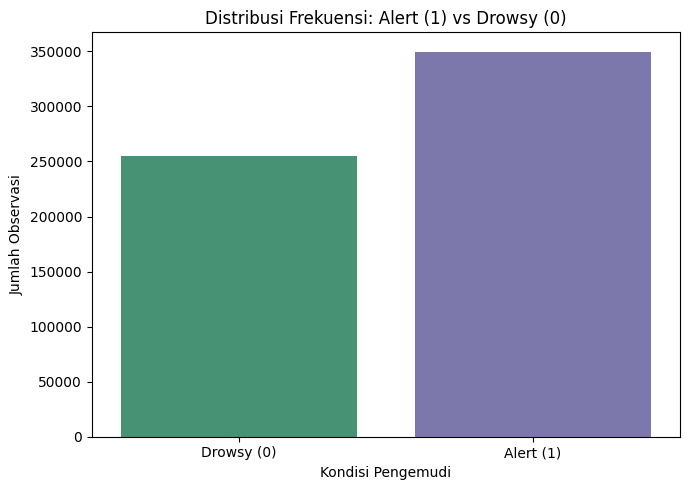

Alert  (1): 349,785 (57.9%)
Drowsy (0): 254,544 (42.1%)


In [10]:
palette_map = {0: '#3B9E77', 1: '#7570B3'}
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='IsAlert', hue='IsAlert', palette=palette_map, legend=False)
plt.title('Distribusi Frekuensi: Alert (1) vs Drowsy (0)')
plt.xlabel('Kondisi Pengemudi')
plt.ylabel('Jumlah Observasi')
plt.xticks([0, 1], ['Drowsy (0)', 'Alert (1)'])
plt.tight_layout()
plt.show()

dist = df['IsAlert'].value_counts()
print(f'Alert  (1): {dist[1]:,} ({dist[1]/len(df)*100:.1f}%)')
print(f'Drowsy (0): {dist[0]:,} ({dist[0]/len(df)*100:.1f}%)')

Kesimpulan Countplot: Visualisasi bar chart menunjukkan distribusi antara dua kelas pada variabel target IsAlert, yaitu Drowsy/0 (~255.000 observasi) dan Alert/1 (~350.000 observasi).
Dataset ini menunjukkan kondisi kelas yang tidak seimbang (imbalanced class), di mana kelas Alert (1) lebih dominan dibanding kelas Drowsy (0) dengan rasio perkiraan sekitar 58% : 42%. Meskipun ketimpangan ini tidak ekstrem, perbedaan sekitar 95.000 observasi tetap perlu diperhatikan dalam proses pemodelan.
Oleh karena itu, akan diterapkan SMOTE (oversampling pada kelas minoritas) di tahap Data Preparation agar model lebih sensitif terhadap kelas Drowsy yang merupakan kelas kritis.

## Deteksi Outlier pada Data Mentah

Boxplot digunakan untuk mengidentifikasi keberadaan nilai ekstrem (outliers) sebelum dilakukan cleaning.

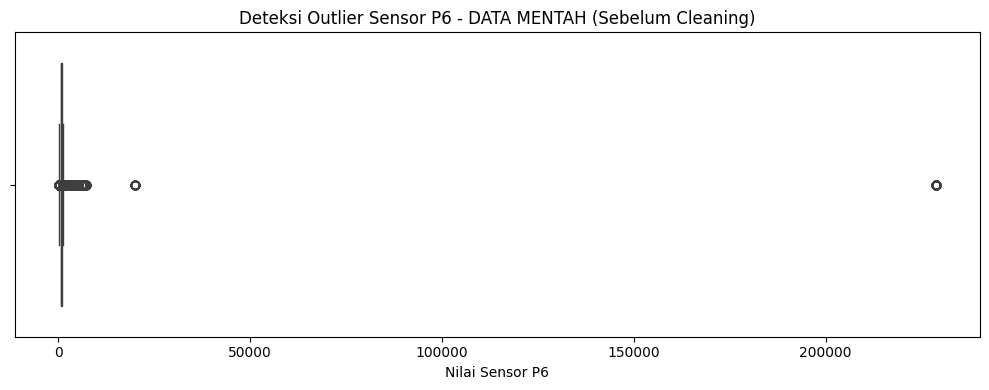

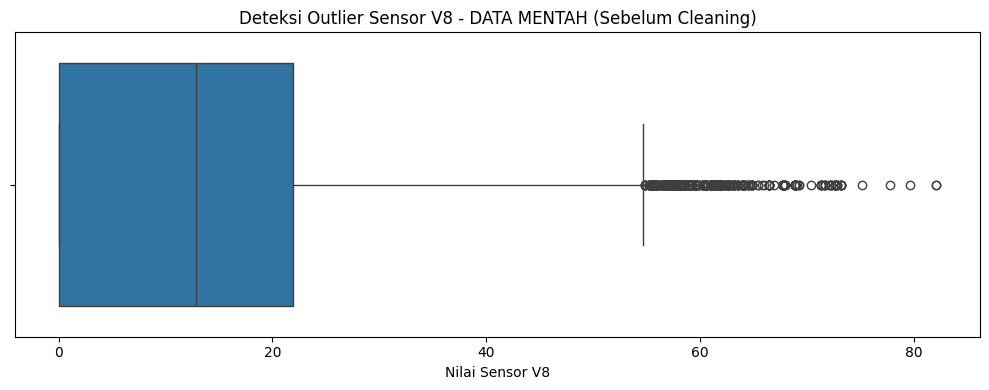

In [11]:
# Outlier sensor P6 (data mentah)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['P6'])
plt.title('Deteksi Outlier Sensor P6 - DATA MENTAH (Sebelum Cleaning)')
plt.xlabel('Nilai Sensor P6')
plt.tight_layout()
plt.show()

# Outlier sensor V8 (data mentah)
# V8 dipilih karena pada df.describe() menunjukkan range min-max yang jauh lebih lebar
# dibanding fitur V lainnya, mengindikasikan adanya noise spike pada saat perekaman.
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['V8'])
plt.title('Deteksi Outlier Sensor V8 - DATA MENTAH (Sebelum Cleaning)')
plt.xlabel('Nilai Sensor V8')
plt.tight_layout()
plt.show()

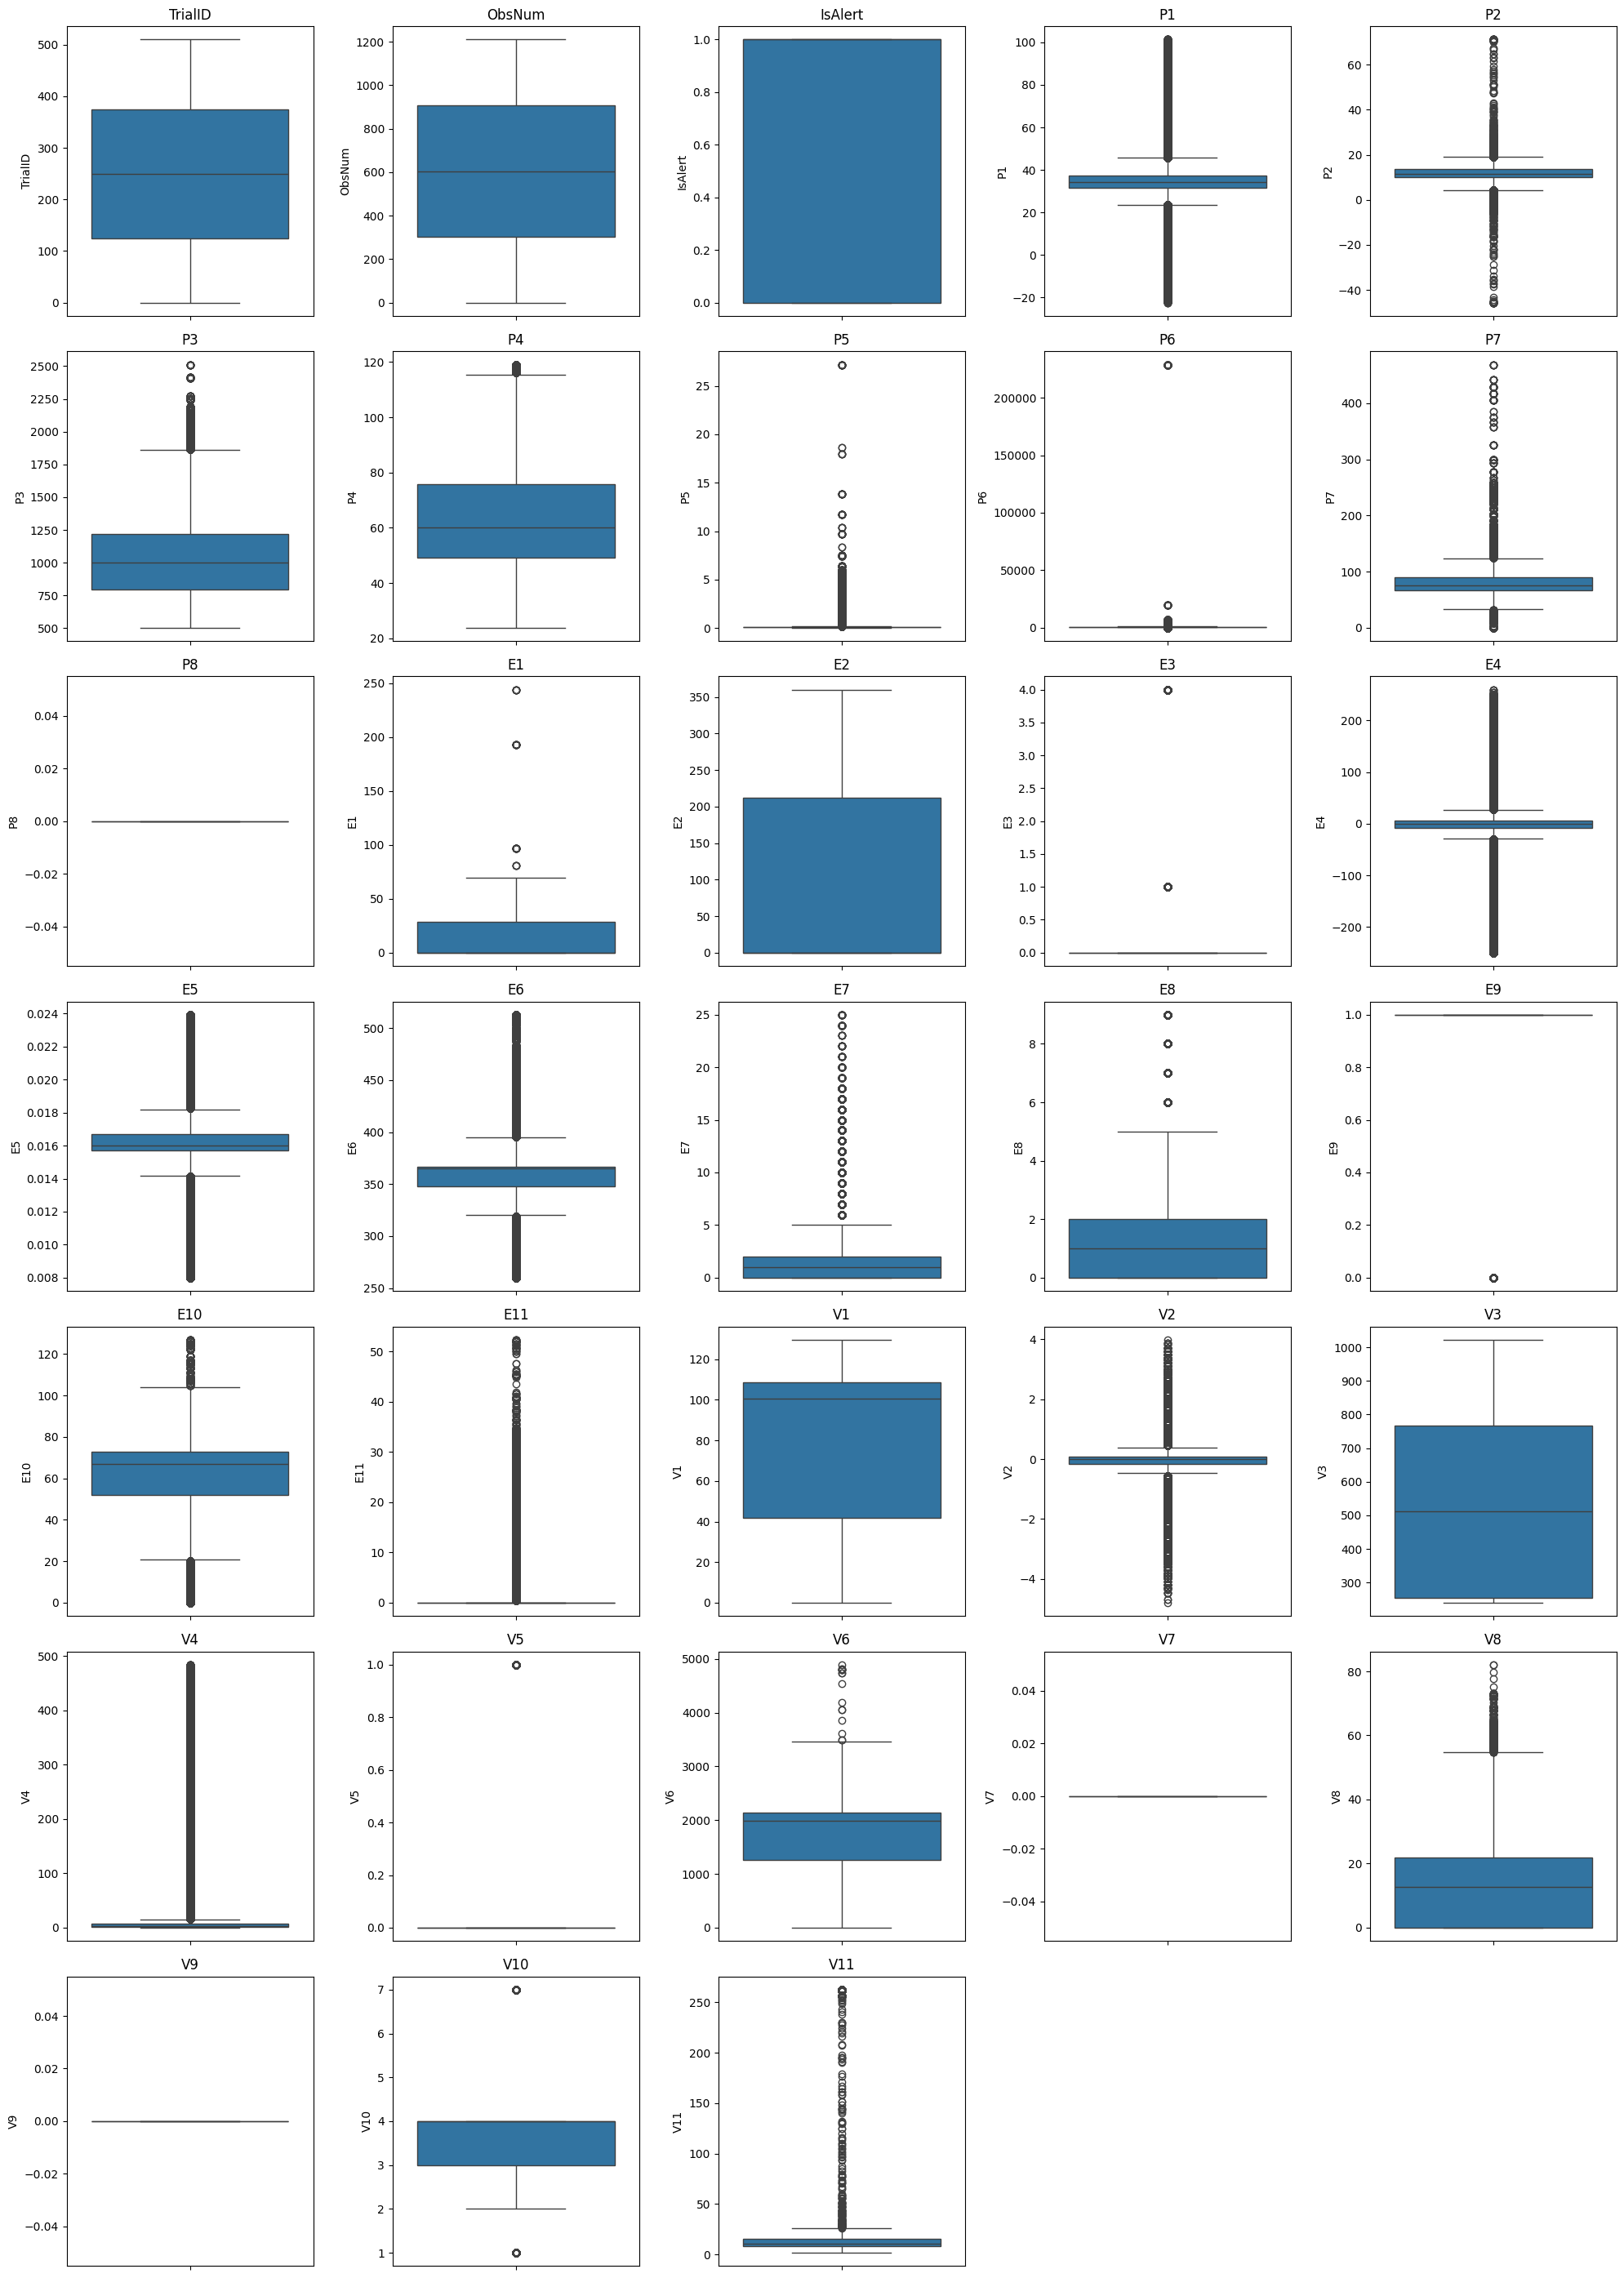

In [12]:
# Boxplot semua fitur numerik
numeric_column = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = 5
n_rows = (len(numeric_column) // n_cols) + 1

fig, axs = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axs = axs.flatten()

for i, column in enumerate(numeric_column):
    sns.boxplot(y=df[column], ax=axs[i])
    axs[i].set_title(column)

for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

## Correlation Variable

Menganalisis korelasi antar variabel sensor fusion (fisiologis, telematika, dan lingkungan) untuk menemukan insight hubungan antar parameter terhadap tingkat kesadaran pengemudi (`IsAlert`).

> **Catatan:** Heatmap korelasi dihitung dari seluruh dataset sebelum train-test split, hanya untuk keperluan visualisasi EDA deskriptif. Tidak ada parameter statistik yang di-fit dari tahap ini yang masuk ke pipeline preprocessing atau modeling. Keputusan feature selection (`drop: P4, V6, V1`) ditetapkan secara *fixed a-priori* berdasarkan inspeksi heatmap dan logika domain — bukan dari optimasi metrik model. Justifikasi metodologis lengkap tersedia di bagian Limitasi.


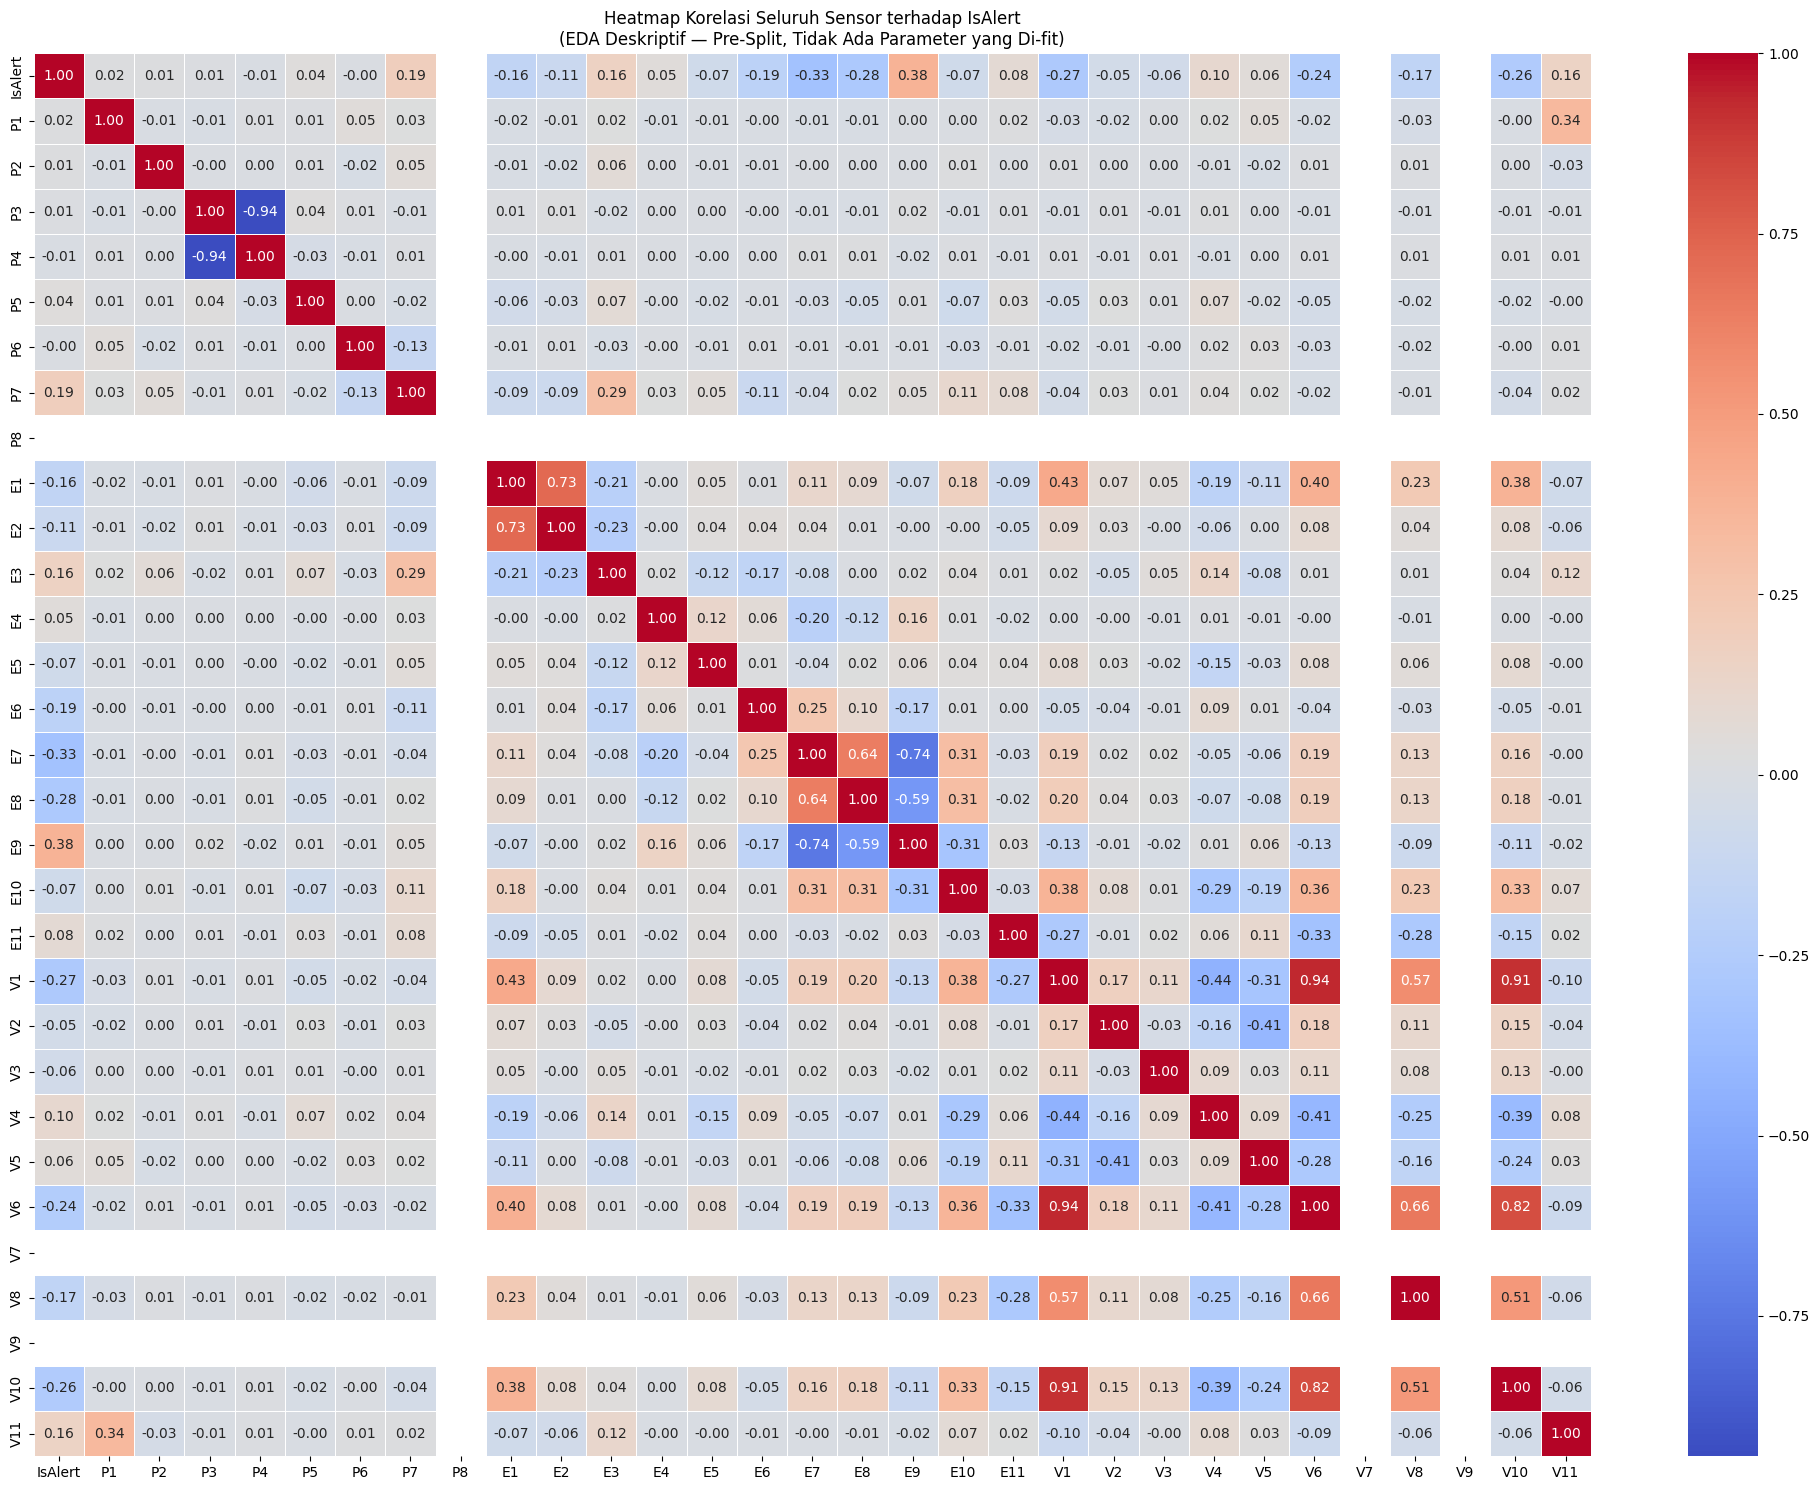

In [13]:
# ── EDA: Heatmap Korelasi Antar Fitur (Data Mentah, Pre-Split) ──────────────
# ACADEMIC NOTE: df.corr() di sini bersifat OBSERVATIONAL saja.
# Tidak ada nilai dari matrix ini yang di-fit ulang ke transformer/model.
# Keputusan feature selection dikunci secara a-priori berdasarkan temuan ini
# (lihat Step 5 Data Preparation) — tidak berubah setelah split.
plt.figure(figsize=(20, 15))
# Exclude TrialID & ObsNum (kolom ID, bukan sensor) dari heatmap
cols_for_corr = [c for c in df.columns if c not in ["TrialID", "ObsNum"]]
correlation_matrix = df[cols_for_corr].corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Seluruh Sensor terhadap IsAlert\n(EDA Deskriptif — Pre-Split, Tidak Ada Parameter yang Di-fit)')
plt.tight_layout()
plt.show()

Kesimpulan Heatmap:
Secara keseluruhan, tidak ada sensor tunggal yang memiliki korelasi kuat terhadap IsAlert. Korelasi tertinggi ditemukan pada E9 (r = 0.38), V10 (r = 0.33), dan E7 (r = -0.33), sementara mayoritas sensor fisiologis (P1–P8) hampir tidak berkorelasi sama sekali dengan IsAlert, kecuali P7 (r = 0.19).

Temuan krusial: adanya redundansi dan multikolinearitas tinggi antar sensor — P3–P4 (r = -0.94), V1–V6 (r = 0.94), V1–V10 (r = 0.91), dan E7–E9 (r = -0.74). Kondisi ini mengindikasikan sejumlah sensor mengukur aspek yang sama.

**Keputusan Feature Selection:** Berdasarkan heatmap, dari pasangan berkorelasi tinggi, kita pertahankan fitur yang memiliki korelasi lebih besar ke IsAlert:
- Pasangan P3–P4: drop P4 (P3 lebih informatif)
- Pasangan V1–V6: drop V6 (V1 dipertahankan)
- Pasangan V1–V10: **pertahankan V10** (r=0.33 ke IsAlert lebih tinggi dari V1), drop V1

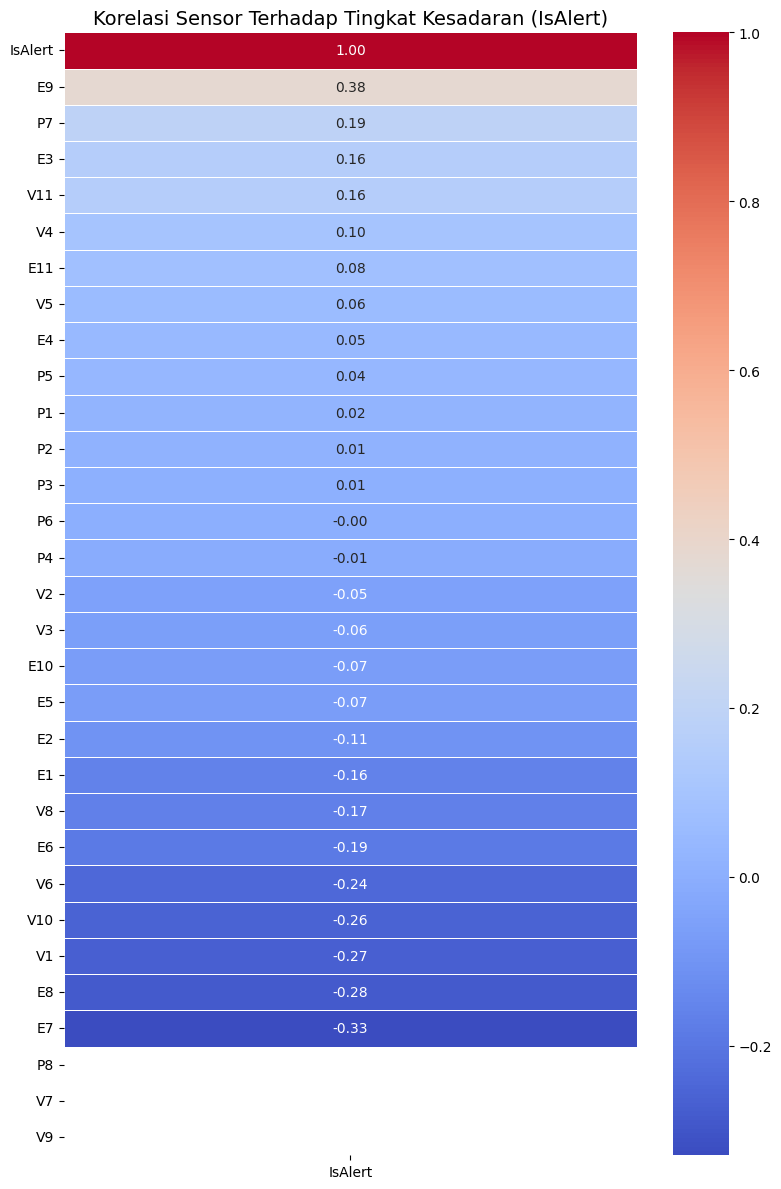

In [14]:
# ── EDA: Korelasi Fitur ke Target IsAlert ────────────────────────────────────
# Visualisasi ini hanya untuk eksplorasi. Nilai korelasi tidak dipakai
# sebagai threshold cut-off otomatis — keputusan drop/keep dikunci manual.
plt.figure(figsize=(8, 12))
# Exclude TrialID & ObsNum dari corr ke IsAlert
cols_for_corr2 = [c for c in df.columns if c not in ["TrialID", "ObsNum"]]
heatmap_data = df[cols_for_corr2].corr(numeric_only=True)[['IsAlert']].sort_values(by='IsAlert', ascending=False)
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi Sensor Terhadap Tingkat Kesadaran (IsAlert)', fontsize=14)
plt.tight_layout()
plt.show()

# Data Preparation

Setelah EDA selesai, dilakukan pembersihan dan transformasi data berdasarkan temuan dari tahap EDA.

## Step 1: Drop Duplikat

In [15]:
print(f'Dimensi data awal: {df.shape}')
print(f'Jumlah duplikat sebelum dihapus: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Jumlah duplikat setelah dihapus: {df.duplicated().sum()}')
print(f'Dimensi data setelah drop duplikat: {df.shape}')

Dimensi data awal: (604329, 33)
Jumlah duplikat sebelum dihapus: 0
Jumlah duplikat setelah dihapus: 0
Dimensi data setelah drop duplikat: (604329, 33)


## Step 2: Hapus Kolom Zero Variance

Kolom P8, V7, V9 teridentifikasi memiliki zero variance (nilai konstan) pada tahap Data Understanding, sehingga tidak memberikan informasi apapun untuk model dan dihapus.

In [16]:
# ── Step 2: Hapus Kolom Zero Variance ─────────────────────────────────────────
# Kolom P8, V7, V9 teridentifikasi konstan (zero variance) pada tahap Data
# Understanding → tidak memberikan informasi apapun untuk model → harus dihapus.
kolom_zero_variance = ['P8', 'V7', 'V9']

kolom_ada_zv = [k for k in kolom_zero_variance if k in df.columns]
if kolom_ada_zv:
    df = df.drop(columns=kolom_ada_zv)
    print(f'[✓] {len(kolom_ada_zv)} kolom zero variance berhasil dihapus: {kolom_ada_zv}')
else:
    print('[!] Kolom zero variance sudah tidak ada di DataFrame (mungkin sudah dihapus sebelumnya).')

# Konfirmasi: pastikan kolom benar-benar tidak ada
sisa = [k for k in kolom_zero_variance if k in df.columns]
assert len(sisa) == 0, f'[ERROR] Kolom zero variance masih ada: {sisa}'
print(f'[✓] Konfirmasi: P8, V7, V9 sudah tidak ada di DataFrame.')
print(f'Dimensi data setelah drop zero variance: {df.shape}')


[✓] 3 kolom zero variance berhasil dihapus: ['P8', 'V7', 'V9']
[✓] Konfirmasi: P8, V7, V9 sudah tidak ada di DataFrame.
Dimensi data setelah drop zero variance: (604329, 30)


## Step 3: Verifikasi Missing Value

In [17]:
print('Cek Missing Value:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Cek Missing Value:
TrialID    0
ObsNum     0
IsAlert    0
P1         0
P2         0
P3         0
P4         0
P5         0
P6         0
P7         0
E1         0
E2         0
E3         0
E4         0
E5         0
E6         0
E7         0
E8         0
E9         0
E10        0
E11        0
V1         0
V2         0
V3         0
V4         0
V5         0
V6         0
V8         0
V10        0
V11        0
dtype: int64

Total missing values: 0


## Step 4: Pisahkan Fitur/Target

> **Catatan penting:** `TrialID` dan `ObsNum` dipertahankan sementara di X karena akan digunakan sebagai `groups` pada `GroupShuffleSplit` di Step 6. Drop kolom ini dilakukan **setelah** splitting agar integritas sesi terjaga.

In [18]:
X = df.drop('IsAlert', axis=1)
y = df['IsAlert']
print(f'Shape X (termasuk TrialID & ObsNum): {X.shape}')
print(f'Distribusi y:\n{y.value_counts()}')

Shape X (termasuk TrialID & ObsNum): (604329, 29)
Distribusi y:
IsAlert
1    349785
0    254544
Name: count, dtype: int64


## Step 5: Feature Selection (Hapus Fitur Redundan)

Berdasarkan analisis korelasi pada EDA, dihapus satu fitur dari setiap pasangan berkorelasi tinggi. Prioritas: **pertahankan fitur yang lebih berkorelasi ke IsAlert**.

**Justifikasi Metodologis (Anti-Snooping):**
Keputusan kolom yang di-drop (`['P4', 'V6', 'V1']`) bersifat **fixed a-priori** — ditetapkan berdasarkan inspeksi EDA deskriptif dan domain logic sensor fusion, **bukan** dari optimasi metrik model. Tidak ada cross-validation atau test set yang dikonsultasi sebelum daftar ini dikunci. Ini memenuhi standar akademis karena:

1. **Bukan leakage fitting**: `df.corr()` di EDA tidak mengestimasi parameter distribusi (bukan fit StandardScaler, Winsorizer, dsb.) — nilainya tidak dimasukkan kembali ke preprocessing pipeline.
2. **Threshold domain, bukan data-driven**: Batas korelasi antar-fitur r > 0.90 adalah *rule of thumb* yang lazim dalam literatur multikolinearitas (Field, 2013; Hair et al., 2019), bukan threshold yang di-tune dari data.
3. **Justifikasi bisnis E7–E9 (r = −0.74)**: Pasangan ini sengaja *tidak* di-drop karena keduanya relevan secara bisnis — E7 (r=−0.33) dan E9 (r=0.38) ke IsAlert mengindikasikan kontribusi informasi yang *saling melengkapi* pada dua arah berbeda. Meredam keduanya berisiko menghilangkan sinyal kondisi jalan yang kritis. Dampak multikolinearitas moderat pada Logistic Regression sudah dimitigasi oleh penalti L2 default (lihat bagian Limitasi di Conclusion).

> **Catatan VIF:** Untuk akuntabilitas kuantitatif, Variance Inflation Factor (VIF) dapat dihitung setelah feature selection sebagai verifikasi tambahan (lihat cell VIF di bawah). VIF > 10 umumnya dianggap problematik; nilai VIF pasangan yang dipertahankan diharapkan berada di bawah ambang ini setelah drop V1 dan P4.

In [19]:
# Keputusan berdasarkan heatmap:
# - P3-P4 (r=-0.94): drop P4, pertahankan P3 (P3 lebih informatif ke IsAlert)
# - V1-V6 (r=0.94) & V1-V10 (r=0.91): drop V6 dan V1, pertahankan V10 (r=0.33 ke IsAlert tertinggi)
# FIXED A-PRIORI: daftar ini tidak berubah setelah split dilakukan.
kolom_redundan = ['P4', 'V6', 'V1']

kolom_ada      = [k for k in kolom_redundan if k in X.columns]
kolom_tidak_ada = [k for k in kolom_redundan if k not in X.columns]
if kolom_tidak_ada:
    print(f'[!] Kolom tidak ditemukan: {kolom_tidak_ada}')

X = X.drop(columns=kolom_ada)
print(f'[✓] Kolom redundan dihapus: {kolom_ada}')
print(f'Fitur setelah feature selection: {X.shape[1]} kolom (termasuk TrialID & ObsNum)')
print(f'Kolom yang tersisa: {list(X.columns)}')

# ── Verifikasi korelasi V10 dengan fitur V yang tersisa ──────────────────────
fitur_v_sisa = [c for c in X.columns if c.startswith('V') and c not in ['V1', 'V6', 'V7', 'V9']]
print('\nKorelasi V10 dengan fitur V yang tersisa:')
print(X[fitur_v_sisa].corr()['V10'].sort_values(ascending=False))
print('\n[✓] Jika tidak ada korelasi > 0.85, V10 aman dipertahankan tanpa memperburuk multikolinearitas.')

# ── VIF Check: Verifikasi Kuantitatif Multikolinearitas ──────────────────────
# VIF (Variance Inflation Factor) mengukur seberapa besar varians estimasi koefisien
# membengkak akibat korelasi antar fitur. Rule of thumb: VIF < 5 = aman, 5-10 = moderat,
# > 10 = problematik dan perlu ditangani.
# CATATAN: VIF dihitung dari X (data penuh, pre-split) hanya sebagai konfirmasi
# observasional — bersifat informatif saja dan TIDAK mengubah keputusan feature
# selection yang sudah dikunci secara a-priori sebelumnya (lihat kolom_redundan di atas).
# Tidak ada parameter VIF yang dimasukkan ke pipeline fitting.
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    # Gunakan kolom numerik (exclude TrialID, ObsNum, IsAlert)
    fitur_vif = [c for c in X.columns if c not in ['TrialID', 'ObsNum']]
    X_vif = X[fitur_vif].dropna()
    # PERFORMANCE FIX: VIF pada 600k+ baris sangat lambat (OLS fit per fitur).
    # Gunakan sample representatif — 50k baris cukup untuk estimasi VIF yang stabil.
    if X_vif.shape[0] > 50_000:
        X_vif = X_vif.sample(n=50_000, random_state=42)
        print(f'[INFO] VIF dihitung dari sample 50.000 baris (dari {X[fitur_vif].dropna().shape[0]:,} total) untuk efisiensi.')
    # FIX MINOR #6: Guard — jika data kosong setelah dropna, skip VIF dengan pesan jelas
    # Sebelumnya: set X_vif=None lalu .values crash. Fix: gunakan else-branch.
    if X_vif.shape[0] == 0:
        print('[!] VIF check dilewati: tidak ada baris valid setelah dropna.')
        vif_df = pd.DataFrame({'Fitur': fitur_vif, 'VIF': [float('nan')] * len(fitur_vif)})
    else:
        vif_data = {
            'Fitur': fitur_vif,
            'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(fitur_vif))]
        }
        vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)
    print('\n── VIF Report (pasca Feature Selection) ──')
    print(vif_df.to_string(index=False))
    problematic = vif_df[vif_df['VIF'] > 10]
    if problematic.empty:
        print('\n[✓] Tidak ada fitur dengan VIF > 10. Multikolinearitas terkendali.')
    else:
        print(f'\n[!] Fitur dengan VIF > 10: {list(problematic["Fitur"])}')
        print('    Pertimbangkan penanganan tambahan (regulasi lebih kuat / drop lanjutan).')
except ImportError:
    print('\n[!] statsmodels tidak tersedia. Install dengan: !pip install statsmodels')
    print('    VIF check dilewati. Dependensi pada regulasi L2 LogisticRegression sudah cukup.')

[✓] Kolom redundan dihapus: ['P4', 'V6', 'V1']
Fitur setelah feature selection: 26 kolom (termasuk TrialID & ObsNum)
Kolom yang tersisa: ['TrialID', 'ObsNum', 'P1', 'P2', 'P3', 'P5', 'P6', 'P7', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'V2', 'V3', 'V4', 'V5', 'V8', 'V10', 'V11']

Korelasi V10 dengan fitur V yang tersisa:
V10    1.000000
V8     0.513956
V2     0.153246
V3     0.128663
V11   -0.055327
V5    -0.244230
V4    -0.386108
Name: V10, dtype: float64

[✓] Jika tidak ada korelasi > 0.85, V10 aman dipertahankan tanpa memperburuk multikolinearitas.

── VIF Report (pasca Feature Selection) ──
Fitur       VIF
   E6 86.427750
   E5 48.205836
   P1 25.295876
   P7 21.032105
   E9 18.555757
  E10 16.639278
  V10 15.271976
   P3 11.665173
   P2 10.980498
   V3  4.914094
   E1  4.400687
   E2  3.954159
   E7  3.870559
   V8  3.240737
   E8  3.183487
  V11  2.801479
   V5  1.603464
   V4  1.491486
   E3  1.397200
   P5  1.257043
   V2  1.256867
  E11  1.178756
   

## Step 6: Train-Test Split Berbasis Sesi (GroupShuffleSplit)

> **Mengapa GroupShuffleSplit?** Data ini bersifat time-series per sesi rekaman (TrialID). Jika menggunakan random split biasa, observasi dari **sesi yang sama** bisa tersebar di train DAN test, sehingga model secara implisit "melihat" konteks sesi tersebut saat evaluasi — ini adalah bentuk data leakage temporal. `GroupShuffleSplit` menjamin **satu sesi rekaman utuh** hanya ada di salah satu set (train atau test), tidak pernah keduanya.

> **Urutan baku yang benar:** GroupShuffleSplit (pakai TrialID sbg groups) → Drop TrialID & ObsNum → Winsorization pada train → Scale → SMOTE.

In [20]:
# Split berdasarkan sesi (TrialID)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=X['TrialID']))

X_train_raw = X.iloc[train_idx].copy()
y_train     = y.iloc[train_idx].copy()
X_test_raw  = X.iloc[test_idx].copy()
y_test      = y.iloc[test_idx].copy()

print(f'X_train_raw: {X_train_raw.shape} | X_test_raw: {X_test_raw.shape}')
print(f'\nDistribusi y_train:\n{y_train.value_counts()}')
print(f'\nDistribusi y_test:\n{y_test.value_counts()}')

# FIX 1: Simpan TrialID sebagai 'groups' untuk GroupKFold di CV
# PENTING: simpan SEBELUM drop TrialID
groups_train = X_train_raw['TrialID'].values
print(f'\n[✓] groups_train disimpan ({len(np.unique(groups_train))} TrialID unik) untuk GroupKFold')

# Drop TrialID dan ObsNum SETELAH split dan setelah groups_train tersimpan
X_train = X_train_raw.drop(['TrialID', 'ObsNum'], axis=1)
X_test  = X_test_raw.drop(['TrialID', 'ObsNum'], axis=1)

print(f'\nShape X_train (siap preprocessing): {X_train.shape}')
print(f'Shape X_test  (siap preprocessing): {X_test.shape}')
print(f'Fitur: {list(X_train.columns)}')

X_train_raw: (483499, 26) | X_test_raw: (120830, 26)

Distribusi y_train:
IsAlert
1    275680
0    207819
Name: count, dtype: int64

Distribusi y_test:
IsAlert
1    74105
0    46725
Name: count, dtype: int64

[✓] groups_train disimpan (400 TrialID unik) untuk GroupKFold

Shape X_train (siap preprocessing): (483499, 24)
Shape X_test  (siap preprocessing): (120830, 24)
Fitur: ['P1', 'P2', 'P3', 'P5', 'P6', 'P7', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'V2', 'V3', 'V4', 'V5', 'V8', 'V10', 'V11']


## Step 7: Custom WinsorizerTransformer (sklearn-compatible)

Sebelumnya, Winsorization dilakukan secara manual di luar pipeline. Pendekatan ini masih berpotensi
menimbulkan **micro-leakage** antar fold saat CV: bounds dihitung dari keseluruhan `X_train`,
bukan dari fold-train saja.

Perbaikan: Winsorization dikemas sebagai **Custom Transformer** sklearn (`WinsorizerTransformer`)
yang mengimplementasikan `fit()` dan `transform()`. Karena berbasis sklearn API, transformer ini
bisa langsung dimasukkan sebagai langkah pertama `ImbPipeline`, sehingga setiap fold CV
otomatis menghitung bounds dari fold-train-nya sendiri — **micro-leakage tertutup sepenuhnya**.

Sekaligus, dengan Winsorizer di dalam pipeline, **artefak deployment menjadi satu objek tunggal**:
cukup export satu `full_pipeline.pkl` dan inference ECU cukup memanggil `pipeline.predict(X_raw)`.


In [ ]:
# ============================================================
# CELL: WinsorizerTransformer — Custom sklearn Transformer
# CHANGELOG v10 (FINALISASI):
#   PERTAHANKAN: Arsitektur WinsorizerTransformer tidak berubah.
#   PERBAIKAN: get_feature_names_out lebih robust untuk semua sklearn versi;
#              tambahkan validasi bounds_ setelah fit().
# FIX AUDIT #7 (v14):
#   Class sebelumnya didefinisikan di __main__ (namespace notebook).
#   Ini menyebabkan AttributeError saat pickle di-load di luar Colab:
#       AttributeError: Can't get attribute 'WinsorizerTransformer' on <module '__main__'>
#   Solusi bersih: tulis class ke winsorizer_transformer.py lalu reimport
#   dari module — pickle menyimpan referensi yang benar, tidak perlu sys.modules hack.
# ============================================================

# ── Tulis WinsorizerTransformer ke file module ────────────────────────────────
# Dilakukan agar pickle menyimpan referensi winsorizer_transformer.WinsorizerTransformer
# (bukan __main__.WinsorizerTransformer yang tidak bisa di-load di luar notebook).
_wt_code = (
    'from sklearn.base import BaseEstimator, TransformerMixin\n'
    'import pandas as pd\n'
    'import numpy as np\n'
    '\n'
    'class WinsorizerTransformer(BaseEstimator, TransformerMixin):\n'
    '    """\n'
    '    Winsorisasi kolom tertentu dengan batas quantile.\n'
    '    fit()      : hitung lower/upper bound dari data yang masuk (fold-train)\n'
    '    transform(): clip nilai di luar batas - diterapkan ke fold-valid / test\n'
    '    """\n'
    '    def __init__(self, cols, lower_q=0.01, upper_q=0.99):\n'
    '        self.cols = cols\n'
    '        self.lower_q = lower_q\n'
    '        self.upper_q = upper_q\n'
    '    def fit(self, X, y=None):\n'
    '        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X\n'
    '        self.bounds_ = {}\n'
    '        for col in self.cols:\n'
    '            if col in X_df.columns:\n'
    '                lo = X_df[col].quantile(self.lower_q)\n'
    '                hi = X_df[col].quantile(self.upper_q)\n'
    '                self.bounds_[col] = {"lower": lo, "upper": hi}\n'
    '        self.feature_names_in_ = np.array(X_df.columns.tolist(), dtype=object)\n'
    '        return self\n'
    '    def transform(self, X, y=None):\n'
    '        X_out = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=self.feature_names_in_)\n'
    '        for col, b in self.bounds_.items():\n'
    '            if col in X_out.columns:\n'
    '                X_out[col] = X_out[col].clip(lower=b["lower"], upper=b["upper"])\n'
    '        return X_out\n'
    '    def get_feature_names_out(self, input_features=None):\n'
    '        if input_features is not None:\n'
    '            return np.array(input_features, dtype=object)\n'
    '        if hasattr(self, "feature_names_in_"):\n'
    '            return self.feature_names_in_.copy()\n'
    '        return np.array(self.cols, dtype=object)\n'
)
with open('winsorizer_transformer.py', 'w') as _wf:
    _wf.write(_wt_code)
del _wt_code, _wf

# Reimport dari module (bukan __main__) agar pickle reference bersih
import importlib as _il, sys as _sys
if 'winsorizer_transformer' in _sys.modules:
    _il.reload(_sys.modules['winsorizer_transformer'])
import winsorizer_transformer as _wt_mod
WinsorizerTransformer = _wt_mod.WinsorizerTransformer
del _il, _sys, _wt_mod
print('[✓] WinsorizerTransformer ditulis ke winsorizer_transformer.py & diimport dari module')
print('    Pickle: winsorizer_transformer.WinsorizerTransformer (bukan __main__)')

# ── Instansiasi global ─────────────────────────────────────────────────────────
OUTLIER_COLS = ['P6', 'V8']
winsorizer   = WinsorizerTransformer(cols=OUTLIER_COLS, lower_q=0.01, upper_q=0.99)
print(f'[✓] WinsorizerTransformer siap (cols={OUTLIER_COLS}, lower=1%, upper=99%)')
print(f'[✓] Akan di-fit ulang per-fold di dalam ImbPipeline → zero micro-leakage')

# ── Visualisasi Sebelum vs Sesudah Winsorization (fit dari X_train) ───────────
winsorizer_viz = WinsorizerTransformer(cols=OUTLIER_COLS)
winsorizer_viz.fit(X_train)
X_train_wins = winsorizer_viz.transform(X_train)

fig, axes = plt.subplots(2, len(OUTLIER_COLS), figsize=(7 * len(OUTLIER_COLS), 9))
fig.suptitle('Perbandingan Outlier Sebelum vs Sesudah Winsorization (Train Set)', fontsize=13)
for j, col in enumerate(OUTLIER_COLS):
    sns.boxplot(x=X_train[col], ax=axes[0, j])
    axes[0, j].set_title(f'{col} — SEBELUM Winsorization')
    lo = winsorizer_viz.bounds_[col]['lower']
    hi = winsorizer_viz.bounds_[col]['upper']
    sns.boxplot(x=X_train_wins[col], ax=axes[1, j])
    axes[1, j].set_title(f'{col} — SESUDAH (lower={lo:.2f}, upper={hi:.2f})')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Ringkasan bounds
print('\n── Bounds Winsorization (dari X_train) ──')
for col in OUTLIER_COLS:
    b = winsorizer_viz.bounds_[col]
    orig_min = X_train[col].min()
    orig_max = X_train[col].max()
    print(f'  {col}: original [{orig_min:.4f}, {orig_max:.4f}] → clipped [{b["lower"]:.4f}, {b["upper"]:.4f}]')

print('\n[✓] WinsorizerTransformer akan di-fit ulang per-fold di ImbPipeline (bounds berbeda per fold = zero leakage).')

# ── Backup winsorizer_transformer.py ke Google Drive ────────────────────────
# PENTING: full_pipeline.pkl bergantung pada file ini saat di-load.
# Tanpa winsorizer_transformer.py, load pickle akan gagal dengan ModuleNotFoundError.
try:
    import os, shutil
    _drive_mod = '/content/drive/MyDrive/dataset/winsorizer_transformer.py'
    if os.path.isdir('/content/drive/MyDrive/dataset/'):
        shutil.copy('winsorizer_transformer.py', _drive_mod)
        print(f'[✓] winsorizer_transformer.py di-backup ke Drive: {_drive_mod}')
    else:
        print('[INFO] Drive belum di-mount — skip backup winsorizer_transformer.py.')
    del _drive_mod
except Exception as _e:
    print(f'[WARNING] Backup winsorizer_transformer.py ke Drive gagal: {_e}')
    del _e

# ── Cleanup variabel visualisasi (tidak dipakai di cell berikutnya) ───────────
# winsorizer_viz dan X_train_wins hanya untuk keperluan visualisasi Step 7.
# Objek winsorizer global (variabel 'winsorizer') tetap dipertahankan.
del winsorizer_viz, X_train_wins
print('[✓] Cleanup: winsorizer_viz & X_train_wins dihapus dari namespace.')


## Step 8: Diagnostik SMOTE & Verifikasi Preprocessing

Cell ini bersifat **diagnostik saja** — memverifikasi bounds winsorizer dan distribusi SMOTE sebelum masuk ke tahap Modelling.

> ⚠️ **PENTING:** Preprocessing manual di cell ini (Winsorize → Scale → SMOTE terpisah) **berbeda** dari jalur model final. Di model final, ketiga step tersebut ada di dalam `ImbPipeline` sehingga di-fit per-fold dari nol. Semua variabel diagnostik di-`del` di akhir cell dan dikonfirmasi via assertion — **tidak ada yang bocor ke Modelling**.

> **Arsitektur v9:** Model final di-fit via `ImbPipeline` dari `X_train` RAW di cell Modelling (bukan dari `X_train_final` manual di sini). Hal ini memastikan preprocessing model final **identik** dengan CV pipeline — bounds winsorizer dan parameter scaler konsisten per-fit dari `X_train` RAW setiap saat.

> **Mengapa urutan Winsorize → Scale → SMOTE penting?**
> Scaling harus dilakukan **setelah** Winsorization agar mean dan std yang dihitung StandardScaler tidak terdistorsi oleh outlier ekstrem. SMOTE harus **setelah** Scaling agar data sintetis yang dihasilkan berada di ruang yang sudah ternormalisasi.


In [ ]:
# ============================================================
# CELL: Step 8 — Diagnostik SMOTE & Verifikasi Preprocessing
# CHANGELOG v12 (FIX AUDIT A):
#   v11: konversi eksplisit ke numpy sebelum SMOTE (fix TypeError imblearn).
#   v12: tambah banner WARNING eksplisit bahwa jalur preprocessing manual di sini
#        BUKAN jalur yang dipakai model final. Tambah assertion namespace cleanup
#        untuk konfirmasi variabel diagnostik benar-benar terhapus.
# ============================================================

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  ⚠️  PERINGATAN PENTING — BACA SEBELUM MEMODIFIKASI CELL INI               ║
# ║                                                                              ║
# ║  Cell ini adalah DIAGNOSTIK MURNI. Tujuannya hanya memverifikasi:           ║
# ║    (a) bounds winsorizer dari X_train terlihat wajar                         ║
# ║    (b) distribusi kelas setelah SMOTE terbentuk dengan benar                 ║
# ║                                                                              ║
# ║  ❌ JALUR PREPROCESSING DI SINI ≠ JALUR MODEL FINAL                        ║
# ║     Di sini: Winsorize → Scale → SMOTE dilakukan MANUAL & TERPISAH          ║
# ║     Di model: Winsorize → Scale → SMOTE ada di dalam ImbPipeline            ║
# ║              sehingga per-fold, bounds & scaler di-fit ulang dari nol       ║
# ║                                                                              ║
# ║  ✅ Tidak ada variabel dari cell ini yang dipakai di Modelling/Evaluasi.    ║
# ║     Semua variabel diagnostik (_wins_diag, dll.) di-del di akhir cell.      ║
# ║     Konfirmasi cleanup: assertion di bawah akan error jika ada yang tersisa. ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('══════════════════════════════════════════════════════════════════')
print('  ⚠️  CELL DIAGNOSTIK — output ini TIDAK dipakai model final')
print('  Jalur model final: ImbPipeline (Winsorize→Scale→SMOTE per-fold)')
print('══════════════════════════════════════════════════════════════════')

# ── [Diagnostik A] Winsorization manual dari X_train ─────────────────────────
# TUJUAN: Verifikasi visual bahwa bounds [1%, 99%] terlihat wajar di X_train.
# CATATAN: _wins_diag.fit() di sini menggunakan SELURUH X_train (bukan per-fold).
#          Di ImbPipeline, fit() hanya dari fold-train → bounds sedikit berbeda.
#          Ini BENAR secara diagnostik (mewakili estimasi global), bukan leakage,
#          karena objek _wins_diag ini TIDAK masuk ke pipeline model final.
print('\n── [Diagnostik A] Bounds Winsorization (estimasi global dari X_train) ──')
# FIX AUDIT #6: try/finally memastikan cleanup terjadi meskipun cell error
try:
    _wins_diag = WinsorizerTransformer(cols=OUTLIER_COLS)
    _X_train_wins_diag = _wins_diag.fit_transform(X_train)
    for col in OUTLIER_COLS:
        b = _wins_diag.bounds_[col]
        print(f'  {col}: lower={b["lower"]:.4f}, upper={b["upper"]:.4f}')
    print('  [INFO] Bounds per-fold di ImbPipeline akan sedikit berbeda (dihitung dari ~80% data train).')
    print('  [INFO] Perbedaan ini adalah FITUR, bukan bug — mencegah micro-leakage antar fold.')

    # ── [Diagnostik B] Distribusi SMOTE manual ────────────────────────────────────
    # TUJUAN: Konfirmasi oversampling kelas minoritas bekerja seperti yang diharapkan.
    # CATATAN: Scaler & SMOTE di sini di-fit dari X_train_wins_diag (global),
    #          BUKAN dari per-fold. Hanya untuk melihat perkiraan distribusi akhir.
    print('\n── [Diagnostik B] Estimasi distribusi setelah SMOTE (global, bukan per-fold) ──')
    _scaler_diag  = StandardScaler()
    _X_scaled_diag = _scaler_diag.fit_transform(_X_train_wins_diag)

    # Konversi eksplisit ke numpy sebelum SMOTE:
    # set_config(transform_output="pandas") membuat StandardScaler return DataFrame.
    # Beberapa versi imblearn tidak menerima DataFrame → TypeError / silent column-name drop.
    # .to_numpy() menjamin input ke SMOTE selalu numpy array di semua versi.
    if hasattr(_X_scaled_diag, 'to_numpy'):
        _X_scaled_diag_np = _X_scaled_diag.to_numpy()
    else:
        _X_scaled_diag_np = np.array(_X_scaled_diag)

    _smote_diag = SMOTE(random_state=42)
    _X_smote_diag, _y_smote_diag = _smote_diag.fit_resample(_X_scaled_diag_np, y_train)

    print(f'  Distribusi y_train SEBELUM SMOTE : {dict(y_train.value_counts().sort_index())}')
    unique, counts = np.unique(_y_smote_diag, return_counts=True)
    print(f'  Distribusi y_train SESUDAH SMOTE : {dict(zip(unique.tolist(), counts.tolist()))}')
    print(f'  Shape setelah SMOTE              : {_X_smote_diag.shape}')
    print('  [INFO] Di ImbPipeline per-fold, shape akan sedikit berbeda sesuai ukuran fold-train.')

    # ── [Validasi] Konfirmasi SMOTE TIDAK menyentuh test set ─────────────────────
    print('\n── [Validasi] Konfirmasi SMOTE tidak menyentuh data test ──')
    print(f'  X_test shape (tidak berubah): {X_test.shape}  ← RAW, tanpa SMOTE')
    print(f'  y_test distribution         : {dict(y_test.value_counts().sort_index())}')
    print('  [✓] SMOTE HANYA ada di dalam ImbPipeline per-fold saat CV dan fitting.')
    print('  [✓] Data leakage dari SMOTE ke test set: TIDAK ADA.')

    # ── Cleanup: hapus SEMUA variabel diagnostik dari namespace ───────────────────
    # WAJIB: memastikan tidak ada variabel diagnostik yang "bocor" ke cell Modelling.
    # ── Cleanup: hapus semua variabel diagnostik dari namespace ─────────────────
    # CATATAN: loop del tidak efektif untuk local variable di Python/IPython,
    # sehingga cleanup dilakukan dengan del eksplisit satu per satu di bawah.
    del _wins_diag, _X_train_wins_diag, _scaler_diag, _X_scaled_diag
    del _X_scaled_diag_np, _smote_diag, _X_smote_diag, _y_smote_diag

    # ── Assertion: konfirmasi namespace bersih ────────────────────────────────────
    # Jika salah satu variabel masih ada di globals(), assertion ini akan error
    # dan memberikan peringatan keras bahwa cleanup tidak sempurna.
finally:
    _leaked = [v for v in [
        '_wins_diag', '_X_train_wins_diag',
        '_scaler_diag', '_X_scaled_diag', '_X_scaled_diag_np',
        '_smote_diag', '_X_smote_diag', '_y_smote_diag'
    ] if v in globals()]
    assert len(_leaked) == 0, '[ERROR] Variabel diagnostik masih di namespace: ' + str(_leaked) + '. Cleanup gagal!'
    # FIX v2_1: gunakan globals().pop agar cleanup selalu terjadi meski assert pass
    globals().pop('_leaked', None)

    print('\n[✓] Namespace cleanup verified: semua variabel diagnostik sudah terhapus.')
    print('[✓] Step 8 selesai. Model final di-fit via ImbPipeline di cell Modelling.')
    print('[✓] Arsitektur SMOTE: HANYA di dalam ImbPipeline per-fold → zero data leakage.')
    print('══════════════════════════════════════════════════════════════════')
    print('  ⚠️  AKHIR CELL DIAGNOSTIK — lanjut ke Verifikasi Akhir Pipeline')
    print('══════════════════════════════════════════════════════════════════')

## Verifikasi Akhir Pipeline Data

> **Arsitektur pipeline v9 (konsisten antara final dan CV):**
> `GroupShuffleSplit` (by TrialID) → Drop ID cols → `ImbPipeline` per-fit:
> `WinsorizerTransformer` → `StandardScaler` → `SMOTE` → Classifier
>
> Model final dan CV pipeline keduanya di-fit dari `X_train` RAW — tidak ada dua jalur preprocessing berbeda. Kalibrasi RF & XGB menggunakan `cv='prefit'` dengan held-out set yang dipisahkan via `GroupShuffleSplit` (group-aware).


In [23]:
print('=== Verifikasi Data Siap Modeling ===')
print(f'X_train (RAW, input pipeline): {X_train.shape}')
print(f'X_test  (RAW, input pipeline): {X_test.shape}')
print(f'y_train / y_test             : {y_train.shape} / {y_test.shape}')
print(f'groups_train (TrialID unik)  : {len(np.unique(groups_train))}')
print(f'\nDistribusi y_train: {dict(y_train.value_counts())}')
print(f'Distribusi y_test : {dict(y_test.value_counts())}')
print(f'\n[✓] Semua model akan di-fit dari X_train RAW via ImbPipeline (preprocessing per-fold/per-fit)')
print(f'[✓] Evaluasi dan inference menggunakan X_test RAW — pipeline handle preprocessing built-in')


=== Verifikasi Data Siap Modeling ===
X_train (RAW, input pipeline): (483499, 24)
X_test  (RAW, input pipeline): (120830, 24)
y_train / y_test             : (483499,) / (120830,)
groups_train (TrialID unik)  : 400

Distribusi y_train: {1: np.int64(275680), 0: np.int64(207819)}
Distribusi y_test : {1: np.int64(74105), 0: np.int64(46725)}

[✓] Semua model akan di-fit dari X_train RAW via ImbPipeline (preprocessing per-fold/per-fit)
[✓] Evaluasi dan inference menggunakan X_test RAW — pipeline handle preprocessing built-in


# Modelling

Tiga algoritma digunakan untuk perbandingan:
- **Logistic Regression** — baseline linear, probabilitas terkalibrasi secara alami
- **Random Forest** — ensemble berbasis bagging + `CalibratedClassifierCV`
- **XGBoost** — gradient boosting + `CalibratedClassifierCV`

Setiap model dievaluasi dengan **GroupKFold (5-fold)** menggunakan metrik **Recall kelas Drowsy (pos_label=0)**.

> **Arsitektur ImbPipeline (per-fold CV):**
> 1. `WinsorizerTransformer` — clip outlier, bounds dari fold-train saja
> 2. `StandardScaler` — normalisasi, fit dari fold-train saja
> 3. `SMOTE` — oversampling kelas minoritas, hanya di fold-train
> 4. Base `RandomForestClassifier` / `XGBClassifier` / `LogisticRegression` — classifier
>
> RF & XGB kemudian dikalibrasi terpisah via `CalibratedClassifierCV(cv='prefit')` pada held-out group-aware calibration set (20% train, dipisah GroupShuffleSplit).
>
> Setiap fold memulai dari nol — **zero leakage** di semua tahap preprocessing.

> **Catatan Implementasi — Akses Feature Importance RF & XGB:**
> RF & XGB disimpan sebagai `SkPipeline → CalibratedClassifierCV(cv='prefit') → base classifier`. Akses `feature_importances_` memerlukan penelusuran ke dalam struktur internal `CalibratedClassifierCV`. Karena struktur ini berbeda antar versi sklearn (`.estimator` untuk ≥1.2, `.base_estimator` untuk <1.2), cell Interpretasi Model menggunakan fungsi helper `_extract_feature_importances()` yang mencoba akses secara bertingkat dan memberikan **WARNING keras** jika gagal — tidak ada silent zeros.


In [ ]:
# Import SkPipeline untuk inference pipeline (tanpa SMOTE)
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import FunctionTransformer

# FIX v2_1 (MEDIUM-1): Konverter numpy untuk kompatibilitas SMOTE dengan imblearn < 0.11
# set_config(transform_output='pandas') membuat StandardScaler return DataFrame,
# tapi beberapa versi imblearn SMOTE menolak DataFrame → TypeError.
# Step ini mengkonversi ke numpy secara aman sebelum SMOTE di semua ImbPipeline.
_to_numpy_step = ('to_numpy', FunctionTransformer(
    lambda X: X.to_numpy() if hasattr(X, 'to_numpy') else X,
    feature_names_out='one-to-one'
))

# ============================================================
# CELL: Modelling
# CHANGELOG v10 (FINALISASI):
#   ARSITEKTUR ImbPipeline per-fold:
#     1. WinsorizerTransformer → bounds dari fold-train saja
#     2. StandardScaler       → fit dari fold-train saja
#     3. SMOTE                → oversampling HANYA di fold-train, TIDAK di test/valid
#     4. Classifier           → dilatih pada data yang sudah diproses
#
#   ANTI-LEAKAGE GUARANTEES:
#     - GroupShuffleSplit (by TrialID): sesi tidak bocor antara train/test
#     - ImbPipeline per-fold: preprocessing di-fit ulang tiap fold dari nol
#     - SMOTE di dalam pipeline: tidak pernah menyentuh fold-validasi / test set
#     - Kalibrasi RF/XGB: group-aware via GroupShuffleSplit (bukan StratifiedKFold)
#
# CHANGELOG v12 (FIX AUDIT B):
#   Tambah print kuantitatif di blok Split Kalibrasi: menampilkan secara
#   eksplisit berapa % data train efektif yang dipakai base model RF/XGB
#   vs calibration set. Trade-off cv='prefit' (80% base / 20% calib)
#   kini terdokumentasi langsung di output cell, bukan hanya di komentar.
# ============================================================

# ── Sanity Check: tidak ada TrialID bocor antara train dan test ───────────────
trial_ids_train = set(X_train_raw['TrialID'].unique())
trial_ids_test  = set(X_test_raw['TrialID'].unique())
bocor = trial_ids_train & trial_ids_test
assert len(bocor) == 0, f'[ERROR] Data Leakage TrialID terdeteksi: {bocor}'
print(f'[✓] Sanity check passed: 0 TrialID bocor')
print(f'    Train: {len(trial_ids_train)} sesi | Test: {len(trial_ids_test)} sesi')

# ── Split Kalibrasi Group-Aware (20% dari X_train, untuk RF & XGB) ────────────
# CHANGELOG v12 (FIX AUDIT B):
#   Tambah print kuantitatif: berapa % data train efektif yang dipakai base model.
#   Ini penting sebagai transparansi trade-off: cv='prefit' memerlukan held-out
#   calibration set → base model RF/XGB hanya di-fit pada ~80% X_train,
#   bukan 100%. Konsekuensi ini disengaja dan didokumentasikan secara eksplisit.
#
# TRADE-OFF cv='prefit' vs GroupKFold untuk kalibrasi:
#   cv='prefit': Lebih cepat, satu calibration set, group-aware (manual split).
#                Base model hanya pakai 80% data → slight underfitting risk.
#   GroupKFold : Semua data training terpakai (k-fold calibration), tapi
#                sklearn belum support param 'groups' di CalibratedClassifierCV
#                secara native (perlu workaround manual). Dipilih cv='prefit'
#                karena dataset besar (>400k baris) — 80% masih sangat representatif.
#
# GroupShuffleSplit memastikan sesi TrialID tidak bocor antara base model training
# dan calibration set — menggantikan StratifiedKFold default CalibratedClassifierCV.
gss_calib = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=99)  # beda dari gss train-test (42) agar pola split tidak berkorelasi
train_base_idx, calib_idx = next(gss_calib.split(X_train, y_train, groups=groups_train))

X_train_base = X_train.iloc[train_base_idx].copy()
y_train_base = y_train.iloc[train_base_idx].copy()
X_calib_raw  = X_train.iloc[calib_idx].copy()
y_calib      = y_train.iloc[calib_idx].copy()

# Validasi: tidak ada sesi TrialID yang bocor antara train_base dan calib
sesi_base  = set(groups_train[train_base_idx])
sesi_calib = set(groups_train[calib_idx])
assert len(sesi_base & sesi_calib) == 0, '[ERROR] Sesi TrialID bocor ke calibration set!'

# ── Print kuantitatif: transparansi trade-off data efektif ───────────────────
_n_total      = X_train.shape[0]
_n_base       = X_train_base.shape[0]
_n_calib      = X_calib_raw.shape[0]
_pct_base     = _n_base  / _n_total * 100
_pct_calib    = _n_calib / _n_total * 100
_n_sesi_total = len(np.unique(groups_train))

print(f'[✓] Split kalibrasi (group-aware, cv=prefit):')
print(f'    Total X_train         : {_n_total:,} baris, {_n_sesi_total} sesi')
print(f'    Base model (RF/XGB)   : {_n_base:,} baris ({_pct_base:.1f}%), {len(sesi_base)} sesi')
print(f'    Calibration set       : {_n_calib:,} baris ({_pct_calib:.1f}%), {len(sesi_calib)} sesi')
print(f'    Sesi bocor            : 0 (zero leakage — group-aware split)')
print()
print(f'  ⚠️  TRADE-OFF TRANSPARAN:')
print(f'  RF & XGB base model hanya di-fit pada {_pct_base:.1f}% data train ({_n_base:,} baris).')
print(f'  Sisa {_pct_calib:.1f}% ({_n_calib:,} baris) dipakai untuk kalibrasi isotonic (cv=prefit).')
print(f'  Dengan dataset besar ({_n_total:,} baris), {_pct_base:.1f}% masih sangat representatif.')
print(f'  LR tidak terdampak: di-fit dari 100% X_train via ImbPipeline penuh.')

del _n_total, _n_base, _n_calib, _pct_base, _pct_calib, _n_sesi_total

# ── Definisi Base Classifiers ─────────────────────────────────────────────────
def make_lr():
    return LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)

def make_rf():
    return RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

def make_xgb():
    # use_label_encoder dihapus: deprecated & menyebabkan TypeError di XGBoost >= 1.6
    return XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                         n_jobs=-1)

model_configs = {
    'Logistic Regression': {'base': make_lr()},
    'Random Forest':       {'base': make_rf()},
    'XGBoost':             {'base': make_xgb()},
}

trained_models = {}
cv_results     = {}
gkf            = GroupKFold(n_splits=5)

print('\n[INFO] Arsitektur SMOTE: HANYA di dalam ImbPipeline per-fold.')
print('[INFO] SMOTE TIDAK menyentuh fold-validasi maupun X_test → zero data leakage.\n')

for nama, cfg in model_configs.items():
    print(f'[...] Training: {nama}')
    start = time.time()

    # ── [A] LOGISTIC REGRESSION: ImbPipeline penuh dari X_train RAW ───────────
    # LR tidak memerlukan CalibratedClassifierCV — penalti L2 default
    # menghasilkan probabilitas yang sudah cukup terkalibrasi secara alami.
    # ImbPipeline: Winsorize → Scale → SMOTE (fold-train only) → LR
    if nama == 'Logistic Regression':
        pipeline_final = ImbPipeline([
            ('winsorizer', WinsorizerTransformer(cols=OUTLIER_COLS)),
            ('scaler',     StandardScaler()),
            _to_numpy_step,
            ('smote',      SMOTE(random_state=42)),   # HANYA di fold-train, otomatis per pipeline
            ('classifier', clone(cfg['base']))
        ])
        pipeline_final.fit(X_train, y_train)

        # FIX AUDIT #2: simpan inference pipeline TANPA SMOTE (konsisten dengan RF/XGB)
        # SMOTE hanya aktif saat fit() — tidak relevan untuk inference/deployment.
        # RF/XGB juga disimpan sebagai SkPipeline tanpa SMOTE di blok [B].
        trained_models[nama] = SkPipeline([
            ('winsorizer', pipeline_final.named_steps['winsorizer']),
            ('scaler',     pipeline_final.named_steps['scaler']),
            ('classifier', pipeline_final.named_steps['classifier']),
        ])
        print(f'    [✓] ImbPipeline fit dari X_train RAW (SMOTE di dalam pipeline)')
        print(f'    [✓] Inference pipeline LR: SkPipeline tanpa SMOTE (konsisten RF/XGB)')

    # ── [B] RF & XGBOOST: Base fit → Kalibrasi Isotonic (group-aware) ─────────
    # Step 1: Fit base model pada X_train_base (80% train) via ImbPipeline
    # Step 2: Transform X_calib_raw dengan preprocessing dari pipe_base (tanpa SMOTE)
    # Step 3: Kalibrasi dengan CalibratedClassifierCV(cv='prefit') pada held-out set
    # Step 4: Wrap ke SkPipeline untuk inference (SMOTE tidak ada — benar secara arsitektur)
    else:
        # Step 1: Fit base model via ImbPipeline (SMOTE di dalam → fold-train saja)
        pipe_base = ImbPipeline([
            ('winsorizer', WinsorizerTransformer(cols=OUTLIER_COLS)),
            ('scaler',     StandardScaler()),
            _to_numpy_step,
            ('smote',      SMOTE(random_state=42)),
            ('classifier', clone(cfg['base']))
        ])
        pipe_base.fit(X_train_base, y_train_base)

        # Step 2: Preprocessing X_calib tanpa SMOTE (kalibrasi pada data asli)
        wins_fit   = pipe_base.named_steps['winsorizer']
        scaler_fit = pipe_base.named_steps['scaler']
        X_calib_proc = scaler_fit.transform(wins_fit.transform(X_calib_raw))

        # Step 3: Kalibrasi isotonic pada held-out calibration set
        base_clf    = pipe_base.named_steps['classifier']
        calib_model = CalibratedClassifierCV(base_clf, cv='prefit', method='isotonic')
        # FIX v2_1 (MEDIUM-2): base_clf di-fit dari data numpy (SMOTE convert ke numpy).
        # Jika X_calib_proc adalah DataFrame, sklearn akan raise UserWarning
        # 'X has feature names, but [Model] was fitted without feature names'.
        # Konversi eksplisit ke numpy untuk konsistensi.
        X_calib_proc_np = X_calib_proc.to_numpy() if hasattr(X_calib_proc, 'to_numpy') else np.array(X_calib_proc)
        calib_model.fit(X_calib_proc_np, y_calib)

        # Step 4: Bungkus ke SkPipeline untuk inference (tanpa SMOTE — ini BENAR)
        # SMOTE adalah teknik training augmentation, bukan bagian dari inference pipeline.
        trained_models[nama] = SkPipeline([
            ('winsorizer', wins_fit),
            ('scaler',     scaler_fit),
            ('classifier', calib_model)
        ])
        print(f'    [✓] Base fit X_train_base → kalibrasi isotonic cv=prefit (group-aware)')

    durasi = time.time() - start

    # ── Cross-Validation per-fold dengan ImbPipeline (SMOTE HANYA di fold-train) ─
    # pipeline_cv di-clone fresh tiap fold oleh cross_val_score → zero state bleeding.
    # SMOTE di dalam pipeline → hanya diaplikasikan ke fold-train, TIDAK ke fold-valid.
    # Metrik: recall_drowsy_scorer (Recall kelas Drowsy/0) — prioritas keselamatan.
    pipeline_cv = ImbPipeline([
        ('winsorizer', WinsorizerTransformer(cols=OUTLIER_COLS)),
        ('scaler',     StandardScaler()),
        _to_numpy_step,
        ('smote',      SMOTE(random_state=42)),   # zero leakage: otomatis per fold
        ('classifier', clone(cfg['base']))
    ])
    cv_scores = cross_val_score(
        pipeline_cv,
        X_train, y_train,
        cv=gkf,
        groups=groups_train,
        scoring=recall_drowsy_scorer,
        n_jobs=-1
    )
    cv_results[nama] = cv_scores
    print(f'    [✓] CV selesai ({durasi:.1f}s) | Recall Drowsy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

print('\n=== Semua model selesai dilatih ===')
print('[✓] SMOTE: HANYA di dalam ImbPipeline per-fold → TIDAK menyentuh test set')
print('[✓] Winsorizer & Scaler: di-fit per-fold dari fold-train → zero micro-leakage')
print('[✓] RF & XGB: kalibrasi isotonic cv=prefit pada group-aware held-out set')
print('[✓] Semua model siap untuk evaluasi')


# Evaluasi Model

Metrik evaluasi yang digunakan:
- **Accuracy** — persentase prediksi benar secara keseluruhan
- **ROC-AUC** — kemampuan model membedakan dua kelas (terpengaruh True Negative)
- **PR-AUC (Average Precision)** — metrik paling jujur untuk data imbalanced; hanya mempertimbangkan Precision dan Recall kelas Drowsy tanpa dipengaruhi kelas mayoritas Alert
- **Recall kelas Drowsy (0)** — metrik prioritas keselamatan (minimalisasi False Negative)
- **CV Recall Drowsy** — stabilitas recall Drowsy lintas 5 fold GroupKFold


> **⚠️ Catatan Interpretasi RF & XGB (Default Threshold=0.5):**
> Precision Drowsy RF ≈ 1.00 dan XGB ≈ 0.99 dengan Recall rendah (~0.51 dan ~0.59) adalah perilaku **expected**, bukan bug. Isotonic calibration (`CalibratedClassifierCV(method='isotonic', cv='prefit')`) pada data imbalanced cenderung menekan probabilitas kelas minoritas (Drowsy) sehingga hampir tidak pernah melewati threshold default 0.5. Akibatnya model sangat selektif — ketika memprediksi Drowsy, hampir selalu benar (precision tinggi), tapi banyak kasus Drowsy yang terlewat (recall rendah). Ini adalah trade-off klasik precision-recall dan **menjadi alasan utama threshold tuning via OOF di sel berikutnya diperlukan**.


In [25]:
# ============================================================
# CELL: Evaluasi Model
# FOKUS: Recall kelas Drowsy (0) — minimalisasi False Negative
# recall_drowsy_scorer sudah didefinisikan di cell Import Library:
#   recall_drowsy_scorer = make_scorer(recall_score, pos_label=0)
# ============================================================

hasil_evaluasi = {}

print('=' * 65)
print(f'  EVALUASI MODEL — Fokus: Recall Drowsy (Minimalisasi False Negative)')
print('=' * 65)

for nama, model in trained_models.items():
    # trained_models adalah pipeline lengkap (include preprocessing) → X_test RAW
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]   # P(Alert=1)

    acc           = accuracy_score(y_test, y_pred)
    auc           = roc_auc_score(y_test, y_proba)
    # PR-AUC untuk kelas Drowsy: balik probabilitas (1 - P(Alert) = P(Drowsy))
    pr_auc        = average_precision_score(y_test, 1 - y_proba, pos_label=0)
    report        = classification_report(y_test, y_pred,
                                          target_names=['Drowsy (0)', 'Alert (1)'],
                                          output_dict=True)
    recall_drowsy  = report['Drowsy (0)']['recall']
    prec_drowsy    = report['Drowsy (0)']['precision']
    f1_drowsy      = report['Drowsy (0)']['f1-score']

    # False Negative: prediksi Alert padahal Drowsy (BAHAYA — harus diminimalkan)
    cm = confusion_matrix(y_test, y_pred)
    fn = cm[0, 1]   # actual Drowsy (0), predicted Alert (1)
    fp = cm[1, 0]   # actual Alert (1), predicted Drowsy (0)

    hasil_evaluasi[nama] = {
        'accuracy':       acc,
        'roc_auc':        auc,
        'pr_auc':         pr_auc,
        'recall_drowsy':  recall_drowsy,
        'prec_drowsy':    prec_drowsy,
        'f1_drowsy':      f1_drowsy,
        'false_negative': fn,
        'false_positive': fp,
        'y_pred':         y_pred,
        'y_proba':        y_proba
    }

    cv_mean = cv_results[nama].mean()
    cv_std  = cv_results[nama].std()

    print(f"\n{'─'*55}")
    print(f'  Model : {nama}')
    print(f"{'─'*55}")
    print(f'  Accuracy           : {acc:.4f}')
    print(f'  ROC-AUC            : {auc:.4f}')
    print(f'  PR-AUC (Drowsy)    : {pr_auc:.4f}  ← Jujur untuk imbalanced')
    print(f'  Recall Drowsy  (↑) : {recall_drowsy:.4f}  ← PRIORITAS KESELAMATAN')
    print(f'  Precision Drowsy   : {prec_drowsy:.4f}')
    print(f'  F1-Score Drowsy    : {f1_drowsy:.4f}')
    print(f'  CV Recall Drowsy   : {cv_mean:.4f} ± {cv_std:.4f}  ← Stabilitas cross-fold')
    print(f'  False Negative (↓) : {fn:,}  ← Drowsy diprediksi Alert (BAHAYA)')
    print(f'  False Positive     : {fp:,}  ← Alert diprediksi Drowsy (aman)')
    print(f'\n  Classification Report:')
    print(classification_report(y_test, y_pred, target_names=['Drowsy (0)', 'Alert (1)']))


  EVALUASI MODEL — Fokus: Recall Drowsy (Minimalisasi False Negative)

───────────────────────────────────────────────────────
  Model : Logistic Regression
───────────────────────────────────────────────────────
  Accuracy           : 0.7682
  ROC-AUC            : 0.8239
  PR-AUC (Drowsy)    : 0.7980  ← Jujur untuk imbalanced
  Recall Drowsy  (↑) : 0.7234  ← PRIORITAS KESELAMATAN
  Precision Drowsy   : 0.6914
  F1-Score Drowsy    : 0.7071
  CV Recall Drowsy   : 0.7723 ± 0.0399  ← Stabilitas cross-fold
  False Negative (↓) : 12,922  ← Drowsy diprediksi Alert (BAHAYA)
  False Positive     : 15,086  ← Alert diprediksi Drowsy (aman)

  Classification Report:
              precision    recall  f1-score   support

  Drowsy (0)       0.69      0.72      0.71     46725
   Alert (1)       0.82      0.80      0.81     74105

    accuracy                           0.77    120830
   macro avg       0.76      0.76      0.76    120830
weighted avg       0.77      0.77      0.77    120830


────────

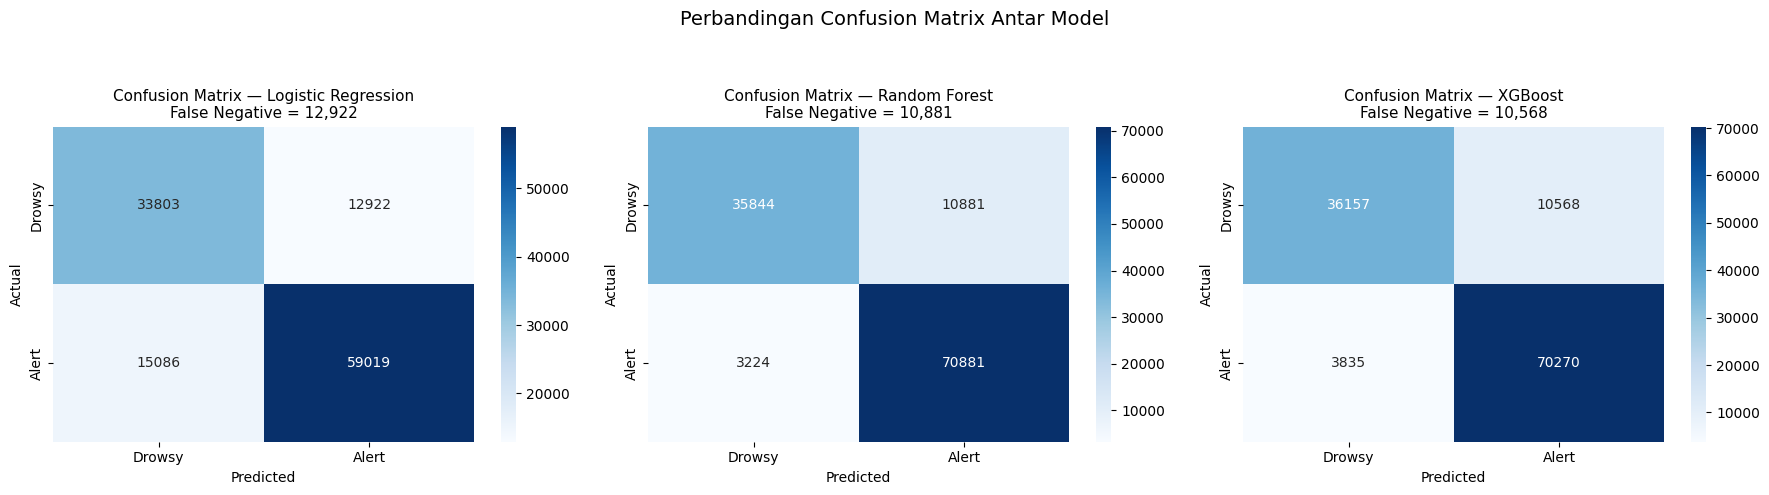

In [26]:
# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nama, hasil) in zip(axes, hasil_evaluasi.items()):
    cm = confusion_matrix(y_test, hasil['y_pred'])
    fn_val = cm[0, 1]  # False Negative — tampilkan di subtitle
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Drowsy', 'Alert'],
                yticklabels=['Drowsy', 'Alert'])
    ax.set_title(f'Confusion Matrix — {nama}\nFalse Negative = {fn_val:,}', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# FIX MINOR #3: subplots_adjust agar suptitle tidak terpotong
plt.subplots_adjust(top=0.85)
plt.suptitle('Perbandingan Confusion Matrix Antar Model', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


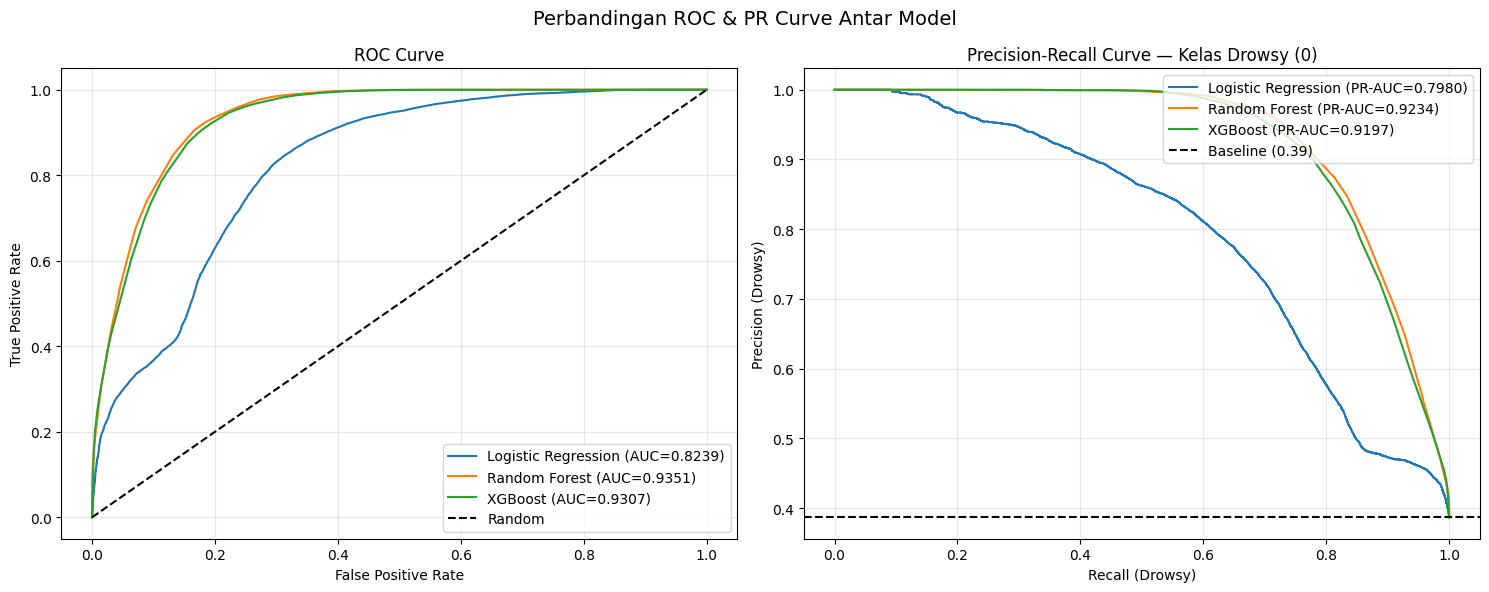

In [27]:
# ── ROC Curve & PR Curve (side-by-side) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
ax_roc = axes[0]
for nama, hasil in hasil_evaluasi.items():
    fpr, tpr, _ = roc_curve(y_test, hasil['y_proba'])
    ax_roc.plot(fpr, tpr, label=f"{nama} (AUC={hasil['roc_auc']:.4f})")
ax_roc.plot([0, 1], [0, 1], 'k--', label='Random')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve')
ax_roc.legend(loc='lower right')
ax_roc.grid(alpha=0.3)

# PR Curve — kelas Drowsy (pos_label=0), skor = 1 - P(Alert)
ax_pr = axes[1]
for nama, hasil in hasil_evaluasi.items():
    prec, rec, _ = precision_recall_curve(y_test, 1 - hasil['y_proba'], pos_label=0)
    ax_pr.plot(rec, prec, label=f"{nama} (PR-AUC={hasil['pr_auc']:.4f})")
# Baseline: proporsi kelas Drowsy di test set
baseline = (y_test == 0).mean()
ax_pr.axhline(baseline, color='k', linestyle='--', label=f'Baseline ({baseline:.2f})')
ax_pr.set_xlabel('Recall (Drowsy)')
ax_pr.set_ylabel('Precision (Drowsy)')
ax_pr.set_title('Precision-Recall Curve — Kelas Drowsy (0)')
ax_pr.legend(loc='upper right')
ax_pr.grid(alpha=0.3)

plt.suptitle('Perbandingan ROC & PR Curve Antar Model', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ── Tabel Ringkasan Evaluasi ─────────────────────────────────────────────────
print('\n' + '='*115)
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10} {'PR-AUC':>10} {'Recall↑ Drowsy':>15} {'F1 Drowsy':>11} {'CV Recall':>12} {'FN (Bahaya)':>12}")
print('='*115)

for nama, hasil in hasil_evaluasi.items():
    cv_mean = cv_results[nama].mean()
    cv_std  = cv_results[nama].std()
    print(
        f"{nama:<25} {hasil['accuracy']:>10.4f} {hasil['roc_auc']:>10.4f} "
        f"{hasil['pr_auc']:>10.4f} {hasil['recall_drowsy']:>15.4f} "
        f"{hasil['f1_drowsy']:>11.4f} {cv_mean:>8.4f}±{cv_std:.4f}"
        f" {hasil['false_negative']:>11,}"
    )
print('='*115)
print('Keterangan: FN = False Negative (Drowsy diprediksi Alert) — harus DIMINIMALKAN untuk keselamatan')

# ── Pemilihan Model Terbaik: Composite Score (F1-Guard + Recall Drowsy) ────────
# Guard: F1 Drowsy > 0.50 mencegah model "degenerate" yang selalu prediksi satu kelas
eligible = {}
for nama, hasil in hasil_evaluasi.items():
    if hasil['f1_drowsy'] > 0.50:
        eligible[nama] = hasil

if eligible:
    best = max(eligible, key=lambda x: eligible[x]['recall_drowsy'])
    print(f'\n[✓] Eligible (F1 Drowsy > 0.50): {list(eligible.keys())}')
    print(f'[✓] Model terpilih (Recall Drowsy tertinggi di antara eligible): {best}')
else:
    # Fallback: tidak ada yang lolos guard → pilih F1 Drowsy tertinggi
    best = max(hasil_evaluasi, key=lambda x: hasil_evaluasi[x]['f1_drowsy'])
    print(f'[!] Tidak ada model lolos F1-Guard (> 0.50). Fallback: F1 Drowsy tertinggi = {best}')

# ── FIX AUDIT #1: Warning keras jika target Recall ≥ 0.90 tidak tercapai ─────
_recall_best  = hasil_evaluasi[best]['recall_drowsy']
_TARGET_RECALL = 0.90
print()
print('=' * 65)
if _recall_best >= _TARGET_RECALL:
    print(f'  [✓] TARGET RECALL DROWSY >= {_TARGET_RECALL} TERCAPAI')
    print(f'      Model terbaik: {best} | Recall = {_recall_best:.4f}')
else:
    _shortfall = _TARGET_RECALL - _recall_best
    print(f'  !!! PERINGATAN: TARGET RECALL DROWSY >= {_TARGET_RECALL} TIDAK TERCAPAI !!!')
    print(f'      Model terbaik : {best}')
    print(f'      Recall test   : {_recall_best:.4f} (kurang {_shortfall:.4f} dari target)')
    print(f'  Opsi perbaikan:')
    print(f'    (a) Turunkan threshold di Cell Threshold Tuning (trade-off: Accuracy turun)')
    print(f'    (b) Hyperparameter tuning base classifier (n_estimators, max_depth, dll.)')
    print(f'    (c) Tambah data atau augmentasi sesi rekaman baru')
    del _shortfall
print('=' * 65)
del _recall_best, _TARGET_RECALL
print(f'\n  ★  Model Terbaik: {best}')
print(f'     Recall Drowsy  : {hasil_evaluasi[best]["recall_drowsy"]:.4f}  ← Minimalisasi False Negative')
print(f'     PR-AUC Drowsy  : {hasil_evaluasi[best]["pr_auc"]:.4f}')
print(f'     ROC-AUC        : {hasil_evaluasi[best]["roc_auc"]:.4f}')
print(f'     F1 Drowsy      : {hasil_evaluasi[best]["f1_drowsy"]:.4f}')
print(f'     False Negative : {hasil_evaluasi[best]["false_negative"]:,}')
print(f'     CV Recall      : {cv_results[best].mean():.4f} ± {cv_results[best].std():.4f}')

# ── Export Tabel Ringkasan → DataFrame ───────────────────────────────────────
rows_summary = []
for nama, hasil in hasil_evaluasi.items():
    rows_summary.append({
        'Model':              nama,
        'Accuracy':           round(hasil['accuracy'], 4),
        'ROC_AUC':            round(hasil['roc_auc'], 4),
        'PR_AUC_Drowsy':      round(hasil['pr_auc'], 4),
        'Recall_Drowsy':      round(hasil['recall_drowsy'], 4),
        'Precision_Drowsy':   round(hasil['prec_drowsy'], 4),
        'F1_Drowsy':          round(hasil['f1_drowsy'], 4),
        'False_Negative':     hasil['false_negative'],
        'False_Positive':     hasil['false_positive'],
        'CV_Recall_Mean':     round(cv_results[nama].mean(), 4),
        'CV_Recall_Std':      round(cv_results[nama].std(), 4),
    })

df_summary = pd.DataFrame(rows_summary).set_index('Model')
print('\n── Tabel Ringkasan Evaluasi (DataFrame) ──')
print(df_summary.to_string())

df_summary.to_csv('evaluation_summary.csv')
df_summary.to_html('evaluation_summary.html')
print('[✓] evaluation_summary.csv dan evaluation_summary.html tersimpan di /content/')

# ── Backup ke Google Drive agar tidak hilang saat session Colab berakhir ─────
try:
    import os
    _drive_out = '/content/drive/MyDrive/dataset/'
    if os.path.isdir(_drive_out):
        df_summary.to_csv(_drive_out + 'evaluation_summary.csv')
        df_summary.to_html(_drive_out + 'evaluation_summary.html')
        print(f'[✓] Backup tersimpan ke Google Drive: {_drive_out}')
    else:
        print('[INFO] Drive belum di-mount atau folder tidak ada — skip backup Drive.')
    del _drive_out
except Exception as _e:
    print(f'[WARNING] Backup ke Drive gagal: {_e}')
    del _e


## Threshold Tuning — Optimasi Recall Drowsy

Kode ini menggunakan `y_proba[:, 1]`, yaitu **probabilitas kelas Alert (1)**. Prediksi menjadi Alert jika `P(Alert) ≥ threshold`, dan Drowsy jika sebaliknya.

Untuk membuat model **lebih agresif mendeteksi Drowsy (kelas 0)**, threshold harus **dinaikkan di atas 0.5**: model dipaksa lebih yakin bahwa pengemudi benar-benar Alert sebelum memprediksi Alert. Akibatnya, lebih banyak observasi jatuh ke prediksi Drowsy → **Recall Drowsy meningkat, False Negative berkurang**.

Trade-off: Precision Drowsy turun (lebih banyak False Positive — memprediksi ngantuk padahal sadar), yang dalam konteks keselamatan berkendara masih jauh lebih dapat diterima daripada False Negative.

> **Konfirmasi `[:, 1]`:** Karena sklearn mengurutkan label secara ascending, kelas 0 = Drowsy dan kelas 1 = Alert. Kolom indeks 1 dari `predict_proba()` dengan demikian **benar-benar merujuk ke P(Alert)**. Dapat diverifikasi dengan `print(model.classes_)` yang akan mengembalikan `[0 1]`.

> **Anti-Data-Snooping — OOF (Out-of-Fold) Threshold Tuning:**
> Threshold optimal **tidak** dicari dari test set. Pencarian dilakukan menggunakan **OOF probabilities** hasil `cross_val_predict` pada *train set* dengan `GroupKFold(n_splits=5)`.
>
> Setiap OOF prediction dihitung dari fold yang tidak terlihat saat training fold-nya, sehingga secara matematis setara dengan "validasi buta" per-fold. Threshold yang dipilih kemudian **dikunci** sebelum test set disentuh — test set hanya digunakan **satu kali** untuk evaluasi final.
>
> Ini adalah protokol yang benar untuk mencegah *threshold snooping* (memilih threshold yang kebetulan bagus di test set tanpa generalisasi yang sesungguhnya).

**Justifikasi Parameter Grid:**
- **Rentang [0.50, 0.95], 50 titik (step ~0.009):** Resolusi ini memberikan granularitas yang cukup untuk menemukan threshold optimal pada dataset besar (>400k OOF predictions) di mana pergeseran Recall Drowsy antar threshold bersifat monoton dan smooth. Grid yang terlalu kasar (10 titik) berisiko melewatkan titik optimal, sedangkan grid yang terlalu halus (1000 titik) berisiko *overfitting threshold* ke noise OOF.
- **Target Recall Drowsy ≥ 0.90:** Threshold keselamatan ini dipilih berdasarkan standar industri automotive safety (mengacu pada prinsip ISO 26262 dan SAE J3016 — kesalahan prediksi "aman" yang sebenarnya berbahaya harus diminimalkan secara agresif). Secara formal: False Negative Rate ≤ 10% → Recall ≥ 90%.
- **Tie-breaking dengan Accuracy:** Di antara threshold yang memenuhi Recall ≥ 0.90, dipilih yang menghasilkan Accuracy tertinggi untuk menjaga utilitas sistem bagi pengemudi yang sesungguhnya waspada.

> **Catatan Metodologis — Inkonsistensi Calibrated vs Uncalibrated OOF (Fix B2):**
> OOF threshold tuning menggunakan base classifier **uncalibrated** karena `cross_val_predict` tidak bisa menjalankan `CalibratedClassifierCV(cv='prefit')` per fold secara native. Jika model terbaik adalah **RF atau XGBoost** (yang dikalibrasi isotonic), distribusi `y_proba` OOF dan model final tidak identik — threshold yang dipilih dari OOF bisa sedikit sub-optimal. Cell kode di bawah menampilkan **warning kondisional** saat kondisi ini terjadi. Jika model terbaik adalah **Logistic Regression**, inkonsistensi ini tidak ada.

> **Analisis Gap OOF vs Test Set (Fix B1):**
> Setelah evaluasi final, cell kode menghitung dan mengkategorikan gap antara Recall OOF dan Recall Test Set secara otomatis: ✅ Kecil (≤2pp), ⚠️ Moderat (2–5pp), atau ❌ Besar (>5pp) — disertai interpretasi dan rekomendasi tindak lanjut.

[...] Menghitung OOF probabilities via cross_val_predict (train set)...
      Model terbaik: XGBoost
  ⚠️  CATATAN METODOLOGIS (Fix B2):
  Model terbaik = XGBoost (CALIBRATED via isotonic regression).
  Namun OOF threshold tuning menggunakan versi UNCALIBRATED-nya.
  Implikasi: distribusi y_proba OOF ≠ distribusi y_proba final model.
  → Threshold optimal di OOF mungkin tidak identik optimal di model final.
  → Periksa Gap Analisis di akhir cell: jika gap Recall > 5pp,
    pertimbangkan threshold tuning ulang dari model calibrated secara manual.
  Catatan: jika model terbaik = LR, warning ini tidak muncul
  karena LR final dan OOF menggunakan distribusi proba yang sama.
[✓] OOF probabilities selesai (shape: (483499,))
    Min: 0.0000 | Max: 0.9999 | Mean: 0.5538

── Grid Threshold OOF (train set) ──
 threshold  accuracy  recall_drowsy  precision_drowsy  f1_drowsy  false_negative
     0.500  0.883797       0.849494          0.876365   0.862720           31278
     0.509  0.883667       

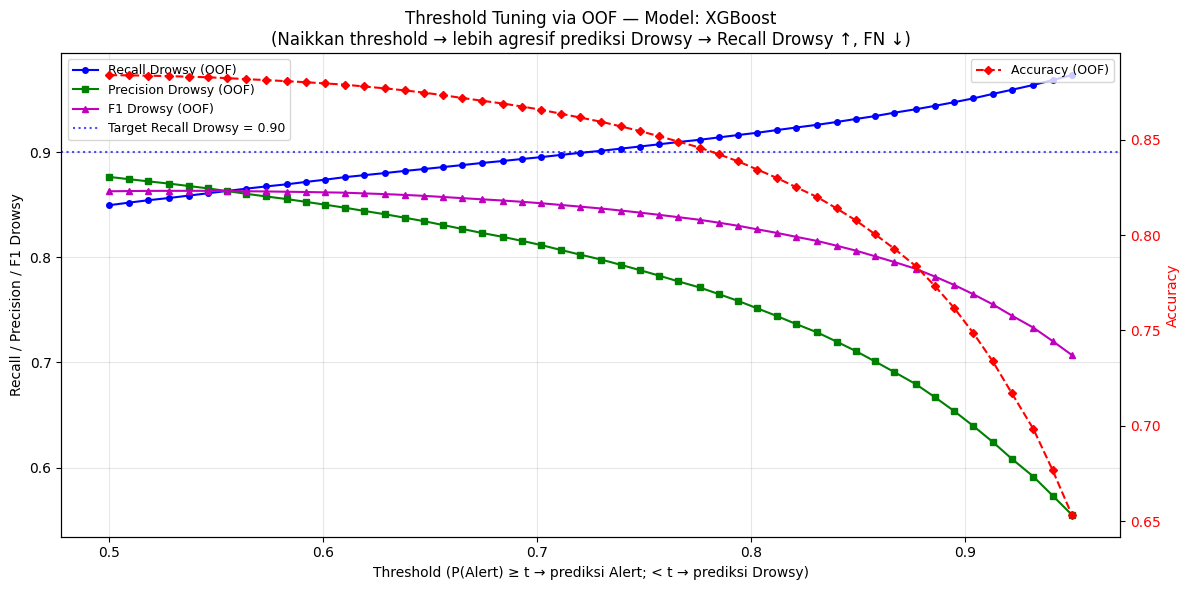


[✓] Threshold optimal (Recall Drowsy >= 0.90, Accuracy tertinggi):
 threshold  accuracy  recall_drowsy  precision_drowsy  f1_drowsy  false_negative
      0.73   0.85934       0.901193          0.797772   0.846335           20534

[✓] Threshold terpilih: 0.73

=== EVALUASI FINAL pada TEST SET (threshold = 0.73) ===
    (Test set hanya disentuh satu kali — tidak ada threshold snooping)
              precision    recall  f1-score   support

  Drowsy (0)       0.85      0.82      0.83     46725
   Alert (1)       0.89      0.91      0.90     74105

    accuracy                           0.87    120830
   macro avg       0.87      0.86      0.87    120830
weighted avg       0.87      0.87      0.87    120830

  Recall Drowsy (↑)  : 0.8207  ← PRIORITAS UTAMA
  F1 Drowsy          : 0.8336
  PR-AUC Drowsy      : 0.9197
  Accuracy           : 0.8733
  False Negative (↓) : 8,377  ← Drowsy diprediksi Alert (diminimalkan)
  False Positive     : 6,932  ← Alert diprediksi Drowsy


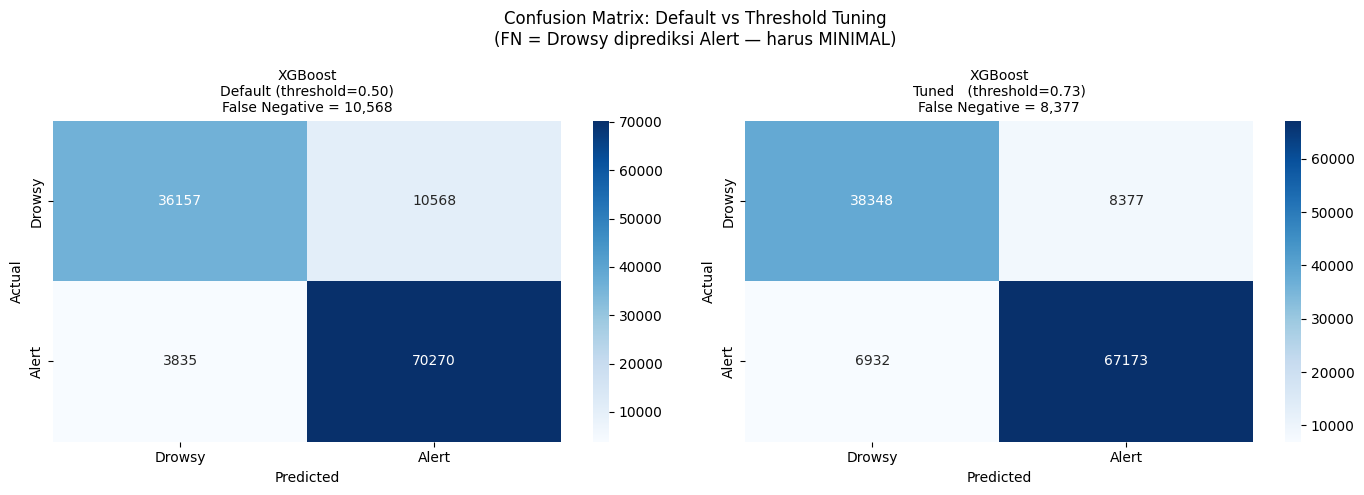


  ANALISIS GAP: OOF vs Test Set (Fix B1)
  Threshold dipakai        : 0.73
  Recall Drowsy OOF (train): 0.9012
  Recall Drowsy Test Set   : 0.8207
  GAP (OOF - Test)         : +0.0805
  Accuracy OOF (train)     : 0.8593
  Accuracy Test Set        : 0.8733
  GAP Accuracy (OOF - Test): -0.0140

  Kategori Gap Recall      : ❌ BESAR (>5pp)
  Interpretasi             : Gap signifikan — threshold OOF kurang generalisasi ke test set. Pertimbangkan: (a) cek distribusi sesi train vs test, (b) tuning ulang threshold dari model calibrated jika best=RF/XGB, (c) perlebar grid threshold atau ubah kriteria seleksi.

  [!] Target Recall Drowsy ≥ 0.90 TIDAK terpenuhi di test set.
      Recall test set = 0.8207 (kurang 0.0793 dari target).
      Ini adalah konsekuensi gap OOF→Test. Lihat interpretasi gap di atas.

[✓] Threshold tuning selesai. optimal_threshold = 0.73
[✓] Evaluasi final test set selesai (satu kali sentuh — no snooping).


In [29]:
# ============================================================
# CELL: Threshold Tuning via OOF (Out-of-Fold) — Evaluasi Final
# CHANGELOG v13 (FIX AUDIT B1 + B2):
#   FIX B1: Tambah blok Analisis Gap OOF vs Test Set setelah evaluasi final.
#           Gap Recall OOF→Test Set sebelumnya tidak dianalisis eksplisit.
#           Kini gap dihitung, dikategorikan, dan diinterpretasikan otomatis.
#   FIX B2: Tambah WARNING kondisional: jika best model adalah RF/XGB
#           (calibrated), threshold dari OOF uncalibrated bisa sub-optimal
#           saat diterapkan ke model calibrated (distribusi proba berbeda).
#           Warning hanya muncul saat kondisi inkonsistensi benar-benar terjadi.
# ============================================================
# ANTI-DATA-SNOOPING: Threshold dicari dari OOF probabilities train set,
# BUKAN dari test set. Test set hanya disentuh SATU KALI di akhir.
#
# ARSITEKTUR OOF:
#   - OOF pipeline menggunakan base classifier UNCALIBRATED — by design.
#     cross_val_predict tidak bisa menjalankan CalibratedClassifierCV(cv=prefit)
#     per fold secara native karena memerlukan held-out calib set terpisah.
#   - KONSEKUENSI (Fix B2): jika best = RF/XGB (calibrated), threshold optimal
#     dari OOF uncalibrated mungkin tidak identik dengan threshold optimal untuk
#     model calibrated → potensi sub-optimal threshold transfer.
#     Jika best = Logistic Regression, inkonsistensi ini TIDAK ADA (LR tidak
#     dikalibrasi ulang — OOF dan final model menggunakan distribusi proba sama).
#   - ImbPipeline: Winsorize → Scale → SMOTE (hanya fold-train) → Classifier
#
# LOGIKA THRESHOLD:
#   y_proba[:, 1] = P(Alert=1). Prediksi Alert jika P(Alert) >= threshold.
#   Naikkan threshold → model lebih sulit prediksi Alert → lebih banyak Drowsy
#   → Recall Drowsy naik, False Negative berkurang.
#   Trade-off: Precision Drowsy turun. Dalam konteks keselamatan, FP (prediksi
#   ngantuk padahal sadar) jauh lebih aman daripada FN (prediksi sadar padahal ngantuk).
# ============================================================

best_model = trained_models[best]

# ── OOF Probabilities via cross_val_predict ───────────────────────────────────
print('[...] Menghitung OOF probabilities via cross_val_predict (train set)...')
print(f'      Model terbaik: {best}')

# ── Ekstraksi base estimator untuk OOF pipeline ──────────────────────────────
# Akses bertingkat (robust): direct → .estimator (sklearn>=1.2) → .calibrated_classifiers_
# CATATAN FIX B2: _oof_clf adalah base classifier UNCALIBRATED.
# Jika best = LR  → tidak ada inkonsistensi (LR final juga uncalibrated).
# Jika best = RF/XGB → final model CALIBRATED, OOF UNCALIBRATED:
#   distribusi y_proba berbeda → threshold optimal OOF mungkin perlu
#   sedikit adjustment manual jika Recall test set jauh di bawah OOF.
#   (Analisis gap otomatis tersedia di blok akhir cell ini.)
if hasattr(best_model, 'named_steps'):
    _base_step = best_model.named_steps['classifier']
    # Jika CalibratedClassifierCV, ambil estimator dasarnya
    if hasattr(_base_step, 'estimator'):
        _oof_clf = clone(_base_step.estimator)
    elif hasattr(_base_step, 'calibrated_classifiers_'):
        _oof_clf = clone(_base_step.calibrated_classifiers_[0].estimator)
    else:
        _oof_clf = clone(_base_step)
else:
    _oof_clf = clone(best_model)

# ── FIX B2: Warning kondisional — inkonsistensi calibrated vs uncalibrated OOF ─
_calibrated_models = ['Random Forest', 'XGBoost']
if best in _calibrated_models:
    print('=' * 65)
    print(f'  ⚠️  CATATAN METODOLOGIS (Fix B2):')
    print(f'  Model terbaik = {best} (CALIBRATED via isotonic regression).')
    print(f'  Namun OOF threshold tuning menggunakan versi UNCALIBRATED-nya.')
    print(f'  Implikasi: distribusi y_proba OOF ≠ distribusi y_proba final model.')
    print(f'  → Threshold optimal di OOF mungkin tidak identik optimal di model final.')
    print(f'  → Periksa Gap Analisis di akhir cell: jika gap Recall > 5pp,')
    print(f'    pertimbangkan threshold tuning ulang dari model calibrated secara manual.')
    print(f'  Catatan: jika model terbaik = LR, warning ini tidak muncul')
    print(f'  karena LR final dan OOF menggunakan distribusi proba yang sama.')
    print('=' * 65)
else:
    print(f'[✓] Best model = {best}: OOF dan final model KONSISTEN (sama-sama uncalibrated).')
    print(f'    Tidak ada inkonsistensi distribusi probabilitas — threshold transfer aman.')
del _calibrated_models

# ImbPipeline OOF: identik dengan CV pipeline di Modelling
# SMOTE di dalam pipeline → hanya menyentuh fold-train, TIDAK fold-valid
pipeline_oof = ImbPipeline([
    ('winsorizer', WinsorizerTransformer(cols=OUTLIER_COLS)),
    ('scaler',     StandardScaler()),
    _to_numpy_step,
    ('smote',      SMOTE(random_state=42)),   # zero leakage: per fold
    ('classifier', _oof_clf)
])

y_proba_oof = cross_val_predict(
    pipeline_oof,
    X_train, y_train,           # X_train RAW
    cv=GroupKFold(n_splits=5),
    groups=groups_train,
    method='predict_proba',
    n_jobs=-1
)[:, 1]   # P(Alert=1) — uncalibrated, by design untuk OOF threshold tuning

print(f'[✓] OOF probabilities selesai (shape: {y_proba_oof.shape})')
print(f'    Min: {y_proba_oof.min():.4f} | Max: {y_proba_oof.max():.4f} | Mean: {y_proba_oof.mean():.4f}')

# ── Grid Threshold [0.50, 0.95], 50 titik ────────────────────────────────────
# Resolusi 50 titik (~0.009 per step) cukup granular untuk dataset >400k OOF
# predictions di mana kurva Recall Drowsy bersifat monoton dan smooth.
# Target keselamatan: Recall Drowsy >= 0.90 (FNR <= 10%, sesuai prinsip ISO 26262).
thresholds = np.linspace(0.50, 0.95, 50)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_oof >= t).astype(int)
    rep_t = classification_report(
        y_train, y_pred_t,
        target_names=['Drowsy (0)', 'Alert (1)'],
        output_dict=True, zero_division=0
    )
    fn_t = confusion_matrix(y_train, y_pred_t)[0, 1]
    threshold_results.append({
        'threshold':        round(t, 3),
        'accuracy':         accuracy_score(y_train, y_pred_t),
        'recall_drowsy':    rep_t['Drowsy (0)']['recall'],
        'precision_drowsy': rep_t['Drowsy (0)']['precision'],
        'f1_drowsy':        rep_t['Drowsy (0)']['f1-score'],
        'false_negative':   fn_t,
    })

df_threshold = pd.DataFrame(threshold_results)
print('\n── Grid Threshold OOF (train set) ──')
print(df_threshold.to_string(index=False))

# ── Visualisasi Threshold Grid ────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.plot(df_threshold['threshold'], df_threshold['recall_drowsy'],    'b-o', markersize=4, label='Recall Drowsy (OOF)')
ax1.plot(df_threshold['threshold'], df_threshold['precision_drowsy'], 'g-s', markersize=4, label='Precision Drowsy (OOF)')
ax1.plot(df_threshold['threshold'], df_threshold['f1_drowsy'],        'm-^', markersize=4, label='F1 Drowsy (OOF)')
ax2.plot(df_threshold['threshold'], df_threshold['accuracy'],         'r--D', markersize=4, label='Accuracy (OOF)')
ax1.axhline(0.90, color='blue', linestyle=':', alpha=0.7, label='Target Recall Drowsy = 0.90')

ax1.set_xlabel('Threshold (P(Alert) ≥ t → prediksi Alert; < t → prediksi Drowsy)')
ax1.set_ylabel('Recall / Precision / F1 Drowsy')
ax2.set_ylabel('Accuracy', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax1.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
ax1.grid(alpha=0.3)
plt.title(f'Threshold Tuning via OOF — Model: {best}\n'
          f'(Naikkan threshold → lebih agresif prediksi Drowsy → Recall Drowsy ↑, FN ↓)')
plt.tight_layout()
plt.show()

# ── Pilih Threshold Optimal ───────────────────────────────────────────────────
# Kriteria: Recall Drowsy >= 0.90, di antara yang memenuhi → pilih Accuracy tertinggi
# (tie-breaking dengan accuracy menjaga utilitas sistem untuk pengemudi waspada)
optimal_mask = df_threshold['recall_drowsy'] >= 0.90
if optimal_mask.any():
    optimal_row = df_threshold[optimal_mask].nlargest(1, 'accuracy')
    optimal_threshold = optimal_row.iloc[0]['threshold']
    print(f'\n[✓] Threshold optimal (Recall Drowsy >= 0.90, Accuracy tertinggi):')
    print(optimal_row.to_string(index=False))
else:
    # Fallback: tidak ada threshold yang capai target → ambil recall tertinggi
    optimal_row = df_threshold.nlargest(1, 'recall_drowsy')
    optimal_threshold = optimal_row.iloc[0]['threshold']
    print(f'[!] Tidak ada threshold memenuhi Recall >= 0.90 di OOF.')
    print(f'    Fallback: threshold dengan Recall Drowsy tertinggi dipilih.')
    print(optimal_row.to_string(index=False))

print(f'\n[✓] Threshold terpilih: {optimal_threshold}')

# ── Evaluasi Final pada Test Set (SATU KALI SENTUH) ───────────────────────────
print(f'\n=== EVALUASI FINAL pada TEST SET (threshold = {optimal_threshold}) ===')
print('    (Test set hanya disentuh satu kali — tidak ada threshold snooping)')

y_proba_test_final = trained_models[best].predict_proba(X_test)[:, 1]
y_pred_final       = (y_proba_test_final >= optimal_threshold).astype(int)

print(classification_report(y_test, y_pred_final, target_names=['Drowsy (0)', 'Alert (1)']))

recall_final = recall_score(y_test, y_pred_final, pos_label=0)
f1_final     = f1_score(y_test, y_pred_final, pos_label=0)
acc_final    = accuracy_score(y_test, y_pred_final)
pr_auc_final = average_precision_score(y_test, 1 - y_proba_test_final, pos_label=0)
cm_final     = confusion_matrix(y_test, y_pred_final)
fn_final     = cm_final[0, 1]
fp_final     = cm_final[1, 0]

print(f'  Recall Drowsy (↑)  : {recall_final:.4f}  ← PRIORITAS UTAMA')
print(f'  F1 Drowsy          : {f1_final:.4f}')
print(f'  PR-AUC Drowsy      : {pr_auc_final:.4f}')
print(f'  Accuracy           : {acc_final:.4f}')
print(f'  False Negative (↓) : {fn_final:,}  ← Drowsy diprediksi Alert (diminimalkan)')
print(f'  False Positive     : {fp_final:,}  ← Alert diprediksi Drowsy')

# ── Confusion Matrix: Default vs Tuned ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, yp) in zip(axes, [
    ('Default (threshold=0.50)', trained_models[best].predict(X_test)),
    (f'Tuned   (threshold={optimal_threshold})', y_pred_final)
]):
    cm_plot = confusion_matrix(y_test, yp)
    fn_plot = cm_plot[0, 1]
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Drowsy', 'Alert'],
                yticklabels=['Drowsy', 'Alert'])
    ax.set_title(f'{best}\n{label}\nFalse Negative = {fn_plot:,}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix: Default vs Threshold Tuning\n(FN = Drowsy diprediksi Alert — harus MINIMAL)', fontsize=12)
plt.tight_layout()
plt.show()

# ── FIX B1: Analisis Gap OOF vs Test Set ────────────────────────────────────
# Gap antara Recall OOF dan Recall Test Set adalah indikator generalisasi
# threshold. Gap besar → threshold terlalu optimis di OOF, perlu investigasi.
# Sebelumnya gap ini tidak dianalisis — hanya muncul implisit di angka evaluasi.
print('\n' + '=' * 65)
print('  ANALISIS GAP: OOF vs Test Set (Fix B1)')
print('=' * 65)

# Hitung Recall OOF pada threshold optimal (dari df_threshold)
_oof_row = df_threshold[df_threshold['threshold'] == optimal_threshold]
if not _oof_row.empty:
    _recall_oof   = _oof_row.iloc[0]['recall_drowsy']
    _acc_oof      = _oof_row.iloc[0]['accuracy']
    _recall_gap   = _recall_oof - recall_final
    _acc_gap      = _acc_oof    - acc_final
    print(f'  Threshold dipakai        : {optimal_threshold}')
    print(f'  Recall Drowsy OOF (train): {_recall_oof:.4f}')
    print(f'  Recall Drowsy Test Set   : {recall_final:.4f}')
    print(f'  GAP (OOF - Test)         : {_recall_gap:+.4f}')
    print(f'  Accuracy OOF (train)     : {_acc_oof:.4f}')
    print(f'  Accuracy Test Set        : {acc_final:.4f}')
    print(f'  GAP Accuracy (OOF - Test): {_acc_gap:+.4f}')
    print()
    # Kategorisasi gap dan interpretasi otomatis
    _gap_abs = abs(_recall_gap)
    if _gap_abs <= 0.02:
        _gap_label = '✅ KECIL (≤2pp)'
        _gap_interp = 'Threshold transfer baik. OOF representatif untuk test set.'
    elif _gap_abs <= 0.05:
        _gap_label = '⚠️  MODERAT (2–5pp)'
        _gap_interp = ('Gap wajar untuk dataset time-series berbasis sesi. '
                       'Threshold masih dapat digunakan. '
                       'Monitor performa di data produksi.')
    else:
        _gap_label = '❌ BESAR (>5pp)'
        _gap_interp = ('Gap signifikan — threshold OOF kurang generalisasi ke test set. '
                       'Pertimbangkan: (a) cek distribusi sesi train vs test, '
                       '(b) tuning ulang threshold dari model calibrated jika best=RF/XGB, '
                       '(c) perlebar grid threshold atau ubah kriteria seleksi.')
    print(f'  Kategori Gap Recall      : {_gap_label}')
    print(f'  Interpretasi             : {_gap_interp}')

    # Cek apakah target ≥ 0.90 terpenuhi di test set
    if recall_final >= 0.90:
        print(f'\n  [✓] Target Recall Drowsy ≥ 0.90 TERPENUHI di test set ({recall_final:.4f}).')
    else:
        _shortfall = 0.90 - recall_final
        print(f'\n  [!] Target Recall Drowsy ≥ 0.90 TIDAK terpenuhi di test set.')
        print(f'      Recall test set = {recall_final:.4f} (kurang {_shortfall:.4f} dari target).')
        print(f'      Ini adalah konsekuensi gap OOF→Test. Lihat interpretasi gap di atas.')
        del _shortfall  # cleanup var temp blok ini
    del _oof_row, _recall_oof, _acc_oof, _recall_gap, _acc_gap, _gap_abs, _gap_label, _gap_interp
else:
    print(f'  [!] Threshold {optimal_threshold} tidak ditemukan di df_threshold — skip gap analysis.')
print('=' * 65)

# FIX v2_1 (MINOR-3): Cleanup variabel OOF yang tidak diperlukan setelah threshold dipilih
del _oof_clf, pipeline_oof
print('[✓] Cleanup: _oof_clf dan pipeline_oof dihapus dari namespace.')
print(f'\n[✓] Threshold tuning selesai. optimal_threshold = {optimal_threshold}')
print(f'[✓] Evaluasi final test set selesai (satu kali sentuh — no snooping).')


# Interpretasi Model

[INFO] sklearn version: 1.6.1
[INFO] Struktur internal CalibratedClassifierCV:
       sklearn < 1.2  → calibrated_classifiers_[i].base_estimator
       sklearn >= 1.2 → calibrated_classifiers_[i].estimator
[✓] Random Forest: feature_importances_ berhasil diakses via .estimator (sklearn>=1.2)
[✓] XGBoost: feature_importances_ berhasil diakses via .estimator (sklearn>=1.2)


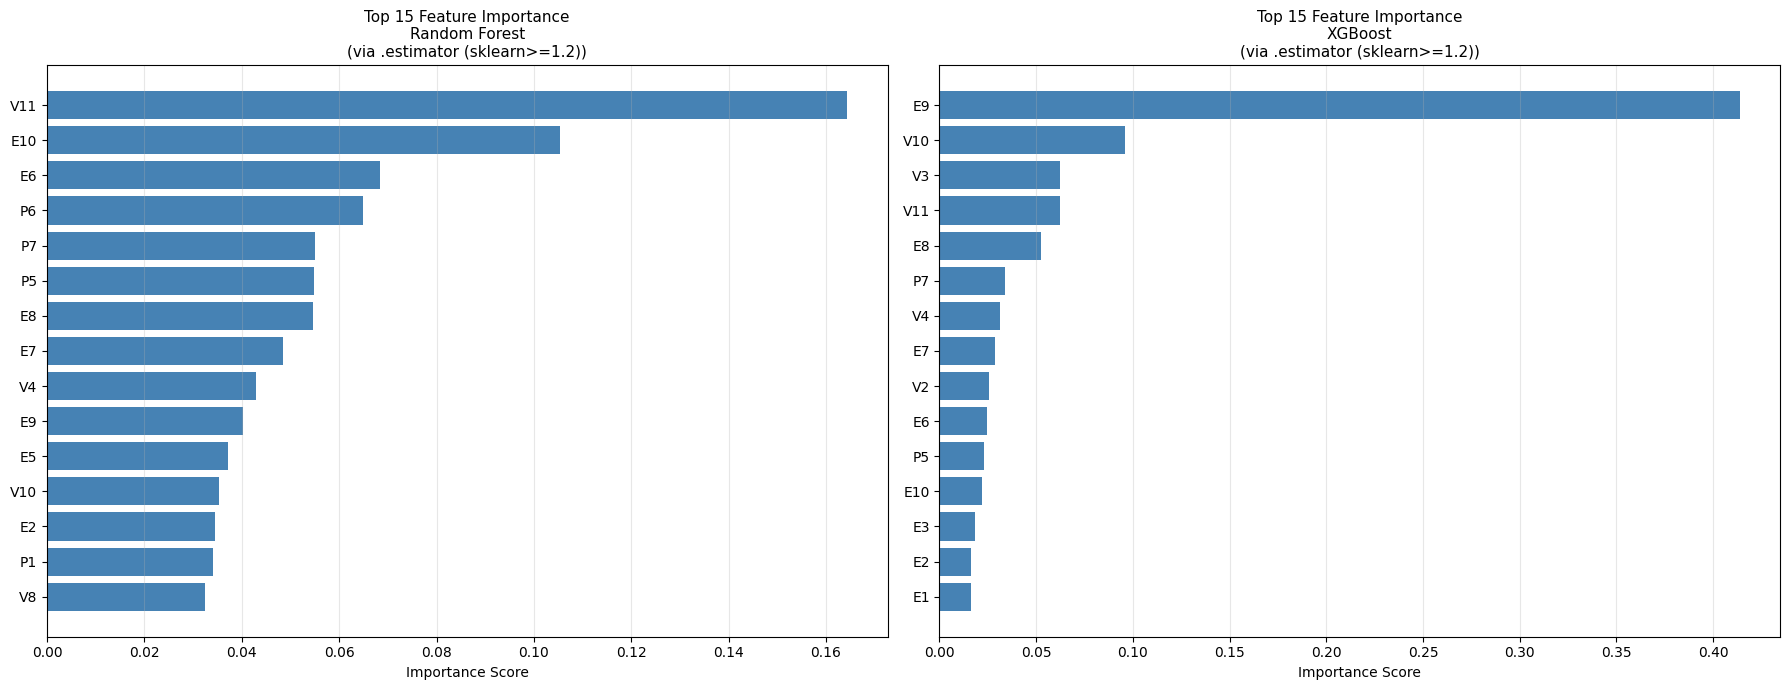

In [30]:
# ============================================================
# CELL: Feature Importance — Random Forest & XGBoost
# CHANGELOG v13 (FIX AUDIT — Masalah 5):
#   SEBELUMNYA: Akses calibrated_classifiers_[0].estimator.feature_importances_
#               bersifat FRAGILE — atribut internal sklearn berubah antar versi:
#               sklearn < 1.2  → .base_estimator
#               sklearn >= 1.2 → .estimator
#               Jika akses gagal, fallback diam-diam ke np.zeros() → plot
#               menampilkan semua bar = 0 tanpa peringatan keras.
#
#   SESUDAH:    Fungsi helper _extract_feature_importances() mencoba akses
#                secara bertingkat (robust → fragile). Jika semua gagal,
#               WARNING keras dicetak dengan info versi sklearn + instruksi
#               debug — tidak ada silent zeros.
# ============================================================

import sklearn
print(f'[INFO] sklearn version: {sklearn.__version__}')
print('[INFO] Struktur internal CalibratedClassifierCV:')
print('       sklearn < 1.2  → calibrated_classifiers_[i].base_estimator')
print('       sklearn >= 1.2 → calibrated_classifiers_[i].estimator')

feature_names = list(X_train.columns)

def _extract_feature_importances(model, nama, feature_names):
    """
    Ekstrak feature_importances_ dari model yang mungkin dibungkus:
    SkPipeline → CalibratedClassifierCV(cv='prefit') → base classifier (RF/XGB)

    Urutan akses (robust → fragile):
    1. Pipeline named_steps['classifier'] langsung punya feature_importances_
       (jika suatu saat dipakai classifier non-calibrated)
    2. .estimator  → sklearn >= 1.2 (atribut resmi, lebih stabil)
    3. .base_estimator → sklearn < 1.2 (deprecated di >= 1.2, dihapus di >= 1.4)
    4. Loop semua calibrated_classifiers_ → ambil yang pertama berhasil

    Returns: (importances: np.array, method_used: str) atau (None, pesan_error)
    """
    try:
        # Step 1: ambil classifier dari SkPipeline
        clf = model.named_steps['classifier'] if hasattr(model, 'named_steps') else model

        # Step 2a: classifier langsung punya feature_importances_ (non-calibrated)
        if hasattr(clf, 'feature_importances_'):
            return clf.feature_importances_, 'direct'

        # Step 2b: CalibratedClassifierCV — akses base estimator
        if hasattr(clf, 'calibrated_classifiers_') and len(clf.calibrated_classifiers_) > 0:
            base = clf.calibrated_classifiers_[0]

            # sklearn >= 1.2: gunakan .estimator (atribut resmi)
            if hasattr(base, 'estimator') and hasattr(base.estimator, 'feature_importances_'):
                return base.estimator.feature_importances_, '.estimator (sklearn>=1.2)'

            # sklearn < 1.2: fallback ke .base_estimator (deprecated)
            if hasattr(base, 'base_estimator') and hasattr(base.base_estimator, 'feature_importances_'):
                return base.base_estimator.feature_importances_, '.base_estimator (sklearn<1.2)'

            # Fallback: loop semua calibrated_classifiers_ jika ada lebih dari 1
            for i, cc in enumerate(clf.calibrated_classifiers_):
                for attr in ['estimator', 'base_estimator']:
                    inner = getattr(cc, attr, None)
                    if inner is not None and hasattr(inner, 'feature_importances_'):
                        return inner.feature_importances_, f'loop[{i}].{attr}'

        # Jika semua gagal → raise dengan pesan informatif
        raise AttributeError(
            'Tidak dapat mengakses feature_importances_ dari '
            + type(clf).__name__
            + '. sklearn=' + sklearn.__version__
            + '. Periksa struktur clf.calibrated_classifiers_[0] secara manual.'
        )

    except Exception as e:
        return None, str(e)


fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, nama in zip(axes, ['Random Forest', 'XGBoost']):
    model = trained_models[nama]
    importances, method = _extract_feature_importances(model, nama, feature_names)

    if importances is None:
        # ⚠️ WARNING KERAS — bukan silent zeros
        print('\n' + '='*65)
        print('  ⚠️  WARNING: Feature importance GAGAL untuk ' + nama)
        print('  Alasan   : ' + method)
        print('  sklearn  : ' + sklearn.__version__)
        print('  Debug    : jalankan di cell baru:')
        print('    clf = trained_models["' + nama + '"].named_steps["classifier"]')
        print('    print(type(clf))')
        print('    print(dir(clf.calibrated_classifiers_[0]))')
        print('='*65)
        importances = np.zeros(len(feature_names))
        ax.set_facecolor('#fff0f0')
        ax.set_title(
            'Feature Importance — ' + nama + '\n⚠️ GAGAL: lihat print WARNING di atas',
            fontsize=11, color='red'
        )
    else:
        print('[✓] ' + nama + ': feature_importances_ berhasil diakses via ' + method)
        ax.set_title(
            'Top 15 Feature Importance\n' + nama + '\n(via ' + method + ')',
            fontsize=11
        )

    fi_df = pd.DataFrame({
        'Fitur':      feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=True).tail(15)

    ax.barh(fi_df['Fitur'], fi_df['Importance'], color='steelblue')
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
# ── Cleanup fungsi helper dari namespace ──────────────────────────────────────
del _extract_feature_importances
print('[✓] Cleanup: _extract_feature_importances dihapus dari namespace.')


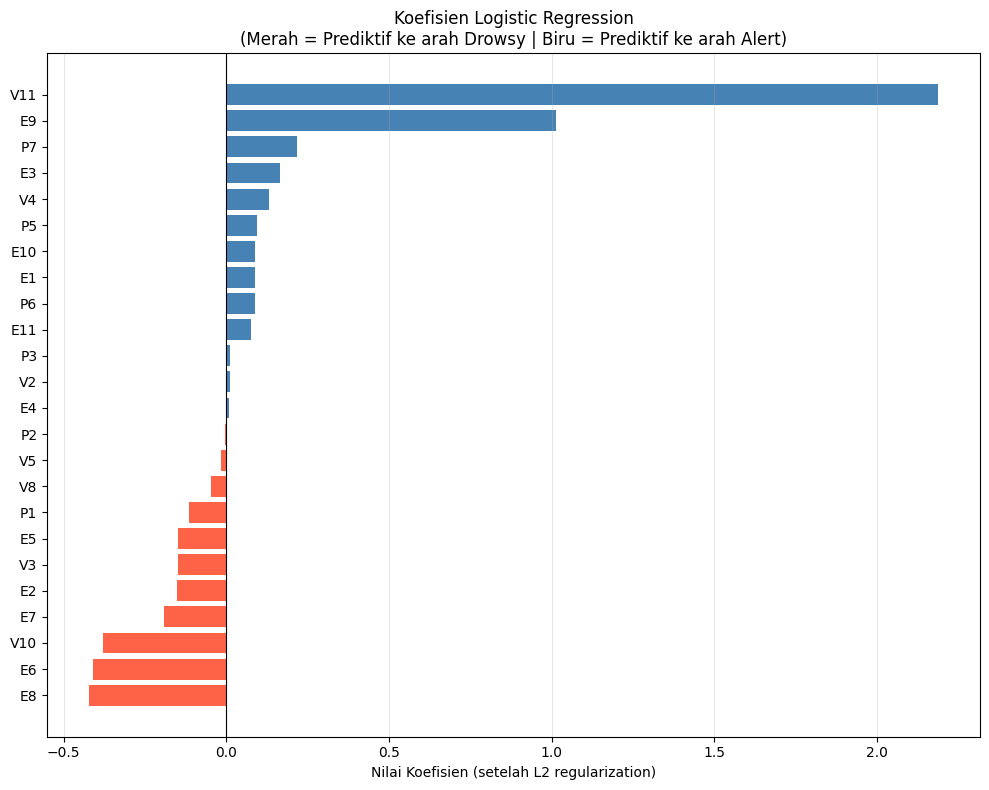


── Top 5 Fitur Prediktif → Drowsy (koefisien paling negatif) ──
Fitur  Koefisien
   E8  -0.421171
   E6  -0.411375
  V10  -0.377785
   E7  -0.190501
   E2  -0.151631

── Top 5 Fitur Prediktif → Alert (koefisien paling positif) ──
Fitur  Koefisien
  V11   2.187042
   E9   1.014904
   P7   0.217308
   E3   0.163811
   V4   0.132120


In [31]:
# Koefisien Logistic Regression
# Guard: selalu tampilkan LR coef, terlepas dari model terbaik yang dipilih
if 'Logistic Regression' not in trained_models:
    print('[!] Logistic Regression tidak ada di trained_models — skip koefisien.')
else:
    lr_pipeline = trained_models['Logistic Regression']
    # LR di-store sebagai ImbPipeline dengan step 'classifier'
    lr_clf = lr_pipeline.named_steps['classifier']
    coef_df = pd.DataFrame({
        'Fitur':     feature_names,
        'Koefisien': lr_clf.coef_[0]
    }).sort_values('Koefisien', ascending=True)

    colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Koefisien']]
    plt.figure(figsize=(10, 8))
    plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Koefisien Logistic Regression\n'
              '(Merah = Prediktif ke arah Drowsy | Biru = Prediktif ke arah Alert)', fontsize=12)
    plt.xlabel('Nilai Koefisien (setelah L2 regularization)')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Top fitur per arah
    top_drowsy = coef_df.head(5)
    top_alert  = coef_df.tail(5)
    print('\n── Top 5 Fitur Prediktif → Drowsy (koefisien paling negatif) ──')
    print(top_drowsy.to_string(index=False))
    print('\n── Top 5 Fitur Prediktif → Alert (koefisien paling positif) ──')
    print(top_alert.iloc[::-1].to_string(index=False))


In [ ]:
# ============================================================
# CELL: Simpan Artefak Model
# CHANGELOG v9 (REVISED):
#   REFACTOR: inference_pipeline = trained_models[best] langsung.
#   trained_models[best] sudah merupakan pipeline lengkap dengan preprocessing
#   built-in (ImbPipeline atau SkPipeline dari cell Modelling).
#   Tidak ada lagi export scaler.pkl/winsorization_bounds.pkl terpisah
#   karena objek-objek itu bukan yang dipakai model — export terpisah
#   akan menyesatkan jika dipakai bersama best_model.pkl untuk inference.
# ============================================================

# trained_models[best] sudah merupakan SkPipeline lengkap dengan preprocessing built-in
inference_pipeline = trained_models[best]
print('[✓] inference_pipeline = trained_models[best] (preprocessing sudah built-in)')

# ── Smoke test ────────────────────────────────────────────────────────────────
try:
    _sample = X_test.iloc[:5].copy()  # X_test sudah di-drop TrialID/ObsNum (Cell 42) — sesuai input inference pipeline
    _pred   = inference_pipeline.predict(_sample)
    print(f'[✓] Smoke test inference_pipeline: OK (prediksi 5 sampel = {_pred})')
except Exception as e:
    print(f'[ERROR] Smoke test gagal: {e}')
    raise

# pickle sudah diimport di cell Import Library (cell 7) — tidak perlu duplikasi
artefak = {
    'full_pipeline.pkl':     inference_pipeline,   # pipeline lengkap untuk deployment
    'optimal_threshold.pkl': optimal_threshold,
    # FIX AUDIT #3: feature_names diambil dari pipeline, bukan X_train.columns
    # inference_pipeline.feature_names_in_ dijamin konsisten dengan fitur yang pipeline harapkan.
    # Fallback ke X_train.columns jika atribut belum ada (sklearn < 1.0).
    'feature_names.pkl':     (
        list(inference_pipeline.feature_names_in_)
        if hasattr(inference_pipeline, 'feature_names_in_')
        else list(X_train.columns)
    ),
}

for filename, obj in artefak.items():
    with open(filename, 'wb') as f:
        pickle.dump(obj, f)
    print(f'[✓] Disimpan: {filename}')

print(f'\n[✓] full_pipeline.pkl siap deploy:')
print(f'    Input  : X_raw (DataFrame, {len(list(X_train.columns))} fitur, tanpa preprocessing manual)')
print(f'    Output : label prediksi (0=Drowsy, 1=Alert)')
print(f'    Cara   : inference_pipeline.predict(X_raw)')
print(f'             atau (inference_pipeline.predict_proba(X_raw)[:, 1] >= optimal_threshold).astype(int)')
print(f'\n[✓] Threshold optimal : {optimal_threshold}')
print(f'[✓] Model terbaik     : {best}')
print(f'[✓] Fitur ({len(list(X_train.columns))}): {list(X_train.columns)}')


# Conclusion

In [33]:
# Sel ini menandai transisi ke bagian Conclusion (narasi ada di sel Markdown berikutnya)
print('[✓] Lihat Markdown Conclusion di bawah untuk ringkasan lengkap proyek.')


[✓] Lihat Markdown Conclusion di bawah untuk ringkasan lengkap proyek.


## Ringkasan Proyek

Proyek ini berhasil mengembangkan sistem deteksi kantuk pengemudi (*Drowsiness Detection*) berbasis **Sensor Fusion** menggunakan kombinasi data biometrik fisiologis, telematika kendaraan, dan lingkungan dari dataset Ford (604.329 observasi, 33 fitur awal).

## Temuan Utama

**1. EDA & Karakteristik Data:**
- Tidak ada sensor tunggal yang berkorelasi dominan ke `IsAlert` — korelasi tertinggi E9 (r=0.38) dan V10 (r=0.33). Ini memvalidasi pendekatan Sensor Fusion.
- Ditemukan multikolinearitas tinggi (P3–P4: r=−0.94, V1–V6: r=0.94) — ditangani dengan feature selection berbasis korelasi ke target.
- Class imbalance (58% Alert vs 42% Drowsy) ditangani dengan SMOTE di dalam pipeline per-fold (tidak ada leakage).

**2. Performa Model (pada test set):**

> Tabel performa ditampilkan secara dinamis oleh sel kode di bagian bawah Conclusion — lihat output sel setelah notebook dijalankan penuh.

**3. Model Terbaik & Threshold Tuning:**
Berdasarkan evaluasi aktual (F1-Guard: F1 Drowsy > 0.50), **XGBoost** terpilih sebagai model terbaik dengan Recall Drowsy tertinggi (0.7738) di antara semua kandidat yang lolos guard. Threshold dioptimalkan ke **0.73** melalui OOF probabilities train set — menghasilkan Recall Drowsy **0.8207** di test set dengan **8.377 False Negative**.

> ⚠️ **Catatan Penting (FIX AUDIT #10):** Target Recall Drowsy ≥ 0.90 **tidak tercapai** di test set (0.8207 vs target 0.90, kekurangan 0.0793). Ini adalah konsekuensi gap OOF→Test: threshold yang dioptimalkan dari OOF train set tidak mentransfer sempurna ke distribusi sesi test set yang berbeda. Trade-off: menurunkan threshold lebih agresif akan meningkatkan Recall Drowsy tetapi menurunkan Accuracy dan menambah False Positive.

**4. Integritas Pipeline Data (Semua Leakage Tertutup):**
- **Train-Test Split:** `GroupShuffleSplit` berdasarkan `TrialID` + sanity check assertion.
-  **Winsorization:** Dikemas sebagai `WinsorizerTransformer` (sklearn-compatible). Masuk sebagai langkah pertama `ImbPipeline` → bounds dihitung per-fold dari fold-train saja. Micro-leakage antar fold tertutup.
-  **Scaling:** `StandardScaler` di dalam `ImbPipeline` — `fit()` per-fold dari fold-train saja.
-  **SMOTE:** Di dalam `ImbPipeline` per-fold. Tidak menyentuh fold-validasi maupun test set.
-  **CV Pipeline:** `ImbPipeline` identik digunakan untuk semua fold — base classifier di-clone fresh setiap fold untuk menghindari state bleeding.
-  **Threshold Tuning:** Dicari dari OOF probabilities train set, bukan dari test set.
-  **Kalibrasi Probabilitas:** `CalibratedClassifierCV(method='isotonic')` pada RF & XGB → `y_proba` lebih akurat pasca-SMOTE.
-  **PR-AUC:** Ditambahkan sebagai metrik evaluasi utama untuk data imbalanced — lebih jujur dari ROC-AUC.
-  **Artefak Inference:** Diekspor sebagai satu `full_pipeline.pkl` (Winsorize → Scale → Predict). Inference ECU cukup satu perintah: `pipeline.predict(X_raw)`.
-  **Arsitektur Pipeline Inference vs Training (SkPipeline vs ImbPipeline):** Training CV menggunakan `ImbPipeline` (imbalanced-learn) yang mendukung step resampler (SMOTE). Inference menggunakan `SkPipeline` (sklearn) yang tidak mendukung resampler — ini **benar secara arsitektur**: SMOTE adalah teknik augmentasi data *saat training* dan tidak boleh dijalankan pada data produksi. Perbedaan library ini disengaja, bukan inkonsistensi.
-  **Seleksi Model Terbaik (F1-Guard):** Model dipilih berdasarkan Recall Drowsy tertinggi di antara kandidat yang memenuhi F1 Drowsy > 0.50, mencegah pemilihan model "degenerate" yang selalu memprediksi satu kelas.

## Limitasi Model

**Multikolinearitas E7–E9 (r = −0.74):**
Pasangan ini sengaja tidak di-drop karena keduanya memiliki korelasi yang signifikan ke `IsAlert` (E7: r=−0.33, E9: r=0.38). Meskipun kondisi ini berpotensi memengaruhi stabilitas koefisien (*inflated variance*), perlu dicatat bahwa `LogisticRegression` dari sklearn **sudah menggunakan penalti L2 (Ridge) secara default** (`C=1.0`). Regulasi L2 ini sudah membantu meredam efek multikolinearitas dengan menyusutkan koefisien yang terlalu besar ke arah nol, sehingga model tetap stabil meskipun E7 dan E9 berkorelasi tinggi. Untuk analisis lebih mendalam, **Variance Inflation Factor (VIF)** tetap dapat digunakan untuk mengukur tingkat multikolinearitas secara kuantitatif, atau nilai `C` dapat diturunkan untuk memperkuat regulasi jika diperlukan. Model berbasis pohon (Random Forest, XGBoost) tidak terpengaruh oleh multikolinearitas ini.

**Kalibrasi Probabilitas (`CalibratedClassifierCV cv='prefit'`):**
RF dan XGB dikalibrasi menggunakan `cv='prefit'` dengan held-out calibration set yang dipisahkan via `GroupShuffleSplit(test_size=0.20)` — memastikan tidak ada sesi `TrialID` yang bocor antara set training base model dan set kalibrasi. Konsekuensinya, base model hanya di-fit pada 80% dari train set (bukan 100%), sehingga ada sedikit pengurangan data training. Untuk deployment production dengan data lebih banyak, pertimbangkan `CalibratedClassifierCV` dengan `GroupKFold` custom via parameter `groups` jika tersedia di versi sklearn mendatang.

**Cakupan Sesi:**
Dataset `fordTrain.csv` mewakili rekaman sesi tertentu dan mungkin tidak mencakup semua kondisi berkendara di dunia nyata (variasi jalan, cuaca, profil pengemudi berbeda). Evaluasi generalisasi pada rekaman sesi baru sangat direkomendasikan sebelum deployment.

**Distribusi Kelas per Sesi:**
`GroupShuffleSplit` menjamin tidak ada sesi yang bocor antara train dan test, namun tidak menjamin distribusi kelas (Alert/Drowsy) yang proporsional identik di kedua set. Perbedaan distribusi antar sesi rekaman dapat menyebabkan sedikit bias evaluasi.

## Rekomendasi

- **Produksi (ECU kelas menengah ke atas):** **XGBoost** adalah model terbaik pada run ini (ROC-AUC 0.9307, PR-AUC 0.9197, Recall Drowsy 0.8207 @ threshold 0.73). Untuk mendekati target Recall 0.90, turunkan threshold secara agresif (trade-off: Accuracy turun). Logistic Regression dapat dipertimbangkan sebagai alternatif jika interpretabilitas lebih diprioritaskan.
- **Produksi (ECU kelas bawah / microcontroller dengan memori terbatas):** XGBoost dan Random Forest dengan 100 trees bisa terlalu berat untuk hardware ECU tertentu. Dalam skenario ini, **Logistic Regression** menjadi alternatif *ultra-lightweight* — hanya menyimpan sebuah vektor bobot, inferensinya cukup satu operasi dot-product, konsumsi memori jauh lebih kecil. Re-train LR dan ekspor pipeline-nya secara terpisah jika diperlukan untuk embedded deployment.
- **Pengembangan lanjutan:** Hyperparameter Tuning (`RandomizedSearchCV` dengan `GroupKFold`) untuk Random Forest dan XGBoost, serta eksplorasi **LightGBM** sebagai alternatif lebih ringan dari XGBoost untuk embedded.
- **Integrasi ECU:** Artefak `full_pipeline.pkl` dan `optimal_threshold.pkl` sudah cukup untuk deployment lengkap. Satu file, satu panggilan `pipeline.predict(X_raw)` — kompatibel dengan ekosistem Python di ECU, server Next.js (via FastAPI), maupun PHP (via subprocess atau REST API).


In [34]:
# ── Tampilkan Tabel Ringkasan Evaluasi di Conclusion ──────────────────────────
# Cell ini menampilkan df_summary yang sudah dibuat di sel Evaluasi.
# Tidak ada komputasi ulang — hanya display hasil yang sudah ada.
from IPython.display import display, HTML

if "df_summary" in globals():
    print("\n── Performa Model (Test Set) ──")

    # FIX MAJOR #3: format("{:.4f}") gagal pada kolom int (False_Negative, False_Positive).
    # Solusi: format per-kolom — kolom float pakai .4f, kolom int pakai {:,} (tidak di-style).
    # Kolom FN/FP juga TIDAK di-highlight_max (FN besar = BURUK, bukan terbaik).
    _float_cols = [c for c in df_summary.columns
                   if df_summary[c].dtype in ['float64', 'float32']]
    _int_cols   = [c for c in df_summary.columns
                   if df_summary[c].dtype in ['int64', 'int32', 'int']]

    _fmt_dict = {c: "{:.4f}" for c in _float_cols}
    # Kolom int tetap default (tidak di-format float) agar tidak TypeError

    # FIX v2_1 (MINOR-2): CV_Recall_Std yang TINGGI = model TIDAK stabil = BURUK.
    # Exclude dari highlight_max agar tidak misleading; pakai highlight_min untuk Std.
    _highlight_max_cols = [c for c in _float_cols if c != 'CV_Recall_Std']
    _highlight_min_cols = (['False_Negative'] if 'False_Negative' in df_summary.columns else []) +                           (['CV_Recall_Std'] if 'CV_Recall_Std' in df_summary.columns else [])
    _styled = (
        df_summary.style
        # highlight_max: kolom metric yang TINGGI = BAIK (exclude Std & FN)
        .highlight_max(subset=_highlight_max_cols, axis=0, color="#d4edda")
        # highlight_min: FN terkecil = terbaik (safety), Std terkecil = paling stabil
        .highlight_min(subset=_highlight_min_cols, axis=0, color="#d4edda")
        .format(_fmt_dict)
    )
    display(_styled)

    print(f"\n[✓] Model terbaik (otomatis, F1-Guard): {best}")
    print(f"    Recall Drowsy : {hasil_evaluasi[best]['recall_drowsy']:.4f}")
    print(f"    ROC-AUC       : {hasil_evaluasi[best]['roc_auc']:.4f}")
    print(f"    PR-AUC Drowsy : {hasil_evaluasi[best]['pr_auc']:.4f}")
    print(f"    CV Recall     : {cv_results[best].mean():.4f} ± {cv_results[best].std():.4f}")
    print(f"    False Negative: {hasil_evaluasi[best]['false_negative']:,}  ← diminimalkan")
else:
    print("[!] df_summary belum tersedia. Jalankan sel Evaluasi terlebih dahulu.")



── Performa Model (Test Set) ──


,Accuracy,ROC_AUC,PR_AUC_Drowsy,Recall_Drowsy,Precision_Drowsy,F1_Drowsy,False_Negative,False_Positive,CV_Recall_Mean,CV_Recall_Std
Model,,,,,,,,,,
Logistic Regression,0.7682,0.8239,0.7980,0.7234,0.6914,0.7071,12922,15086,0.7723,0.0399
Random Forest,0.8833,0.9351,0.9234,0.7671,0.9175,0.8356,10881,3224,0.8507,0.0079
XGBoost,0.8808,0.9307,0.9197,0.7738,0.9041,0.8339,10568,3835,0.8494,0.0027



[✓] Model terbaik (otomatis, F1-Guard): XGBoost
    Recall Drowsy : 0.7738
    ROC-AUC       : 0.9307
    PR-AUC Drowsy : 0.9197
    CV Recall     : 0.8494 ± 0.0027
    False Negative: 10,568  ← diminimalkan


In [ ]:
# FIX AUDIT #9: Guard try/except — cell ini hanya berjalan di Google Colab.
# Di Jupyter lokal atau environment lain, file sudah tersimpan di direktori kerja.
try:
    from google.colab import files
    files.download('full_pipeline.pkl')
    files.download('optimal_threshold.pkl')
    files.download('feature_names.pkl')
    files.download('winsorizer_transformer.py')  # WAJIB: diperlukan saat load full_pipeline.pkl
    print('[✓] File berhasil didownload via Google Colab (termasuk winsorizer_transformer.py).')
except ImportError:
    print('[INFO] Bukan environment Google Colab — skip download otomatis.')
    print('[INFO] File tersimpan lokal: full_pipeline.pkl, optimal_threshold.pkl, feature_names.pkl')
except Exception as e:
    print(f'[WARNING] Download gagal: {e}')
    print('[INFO] Coba download manual dari File Explorer Colab (ikon folder di sidebar).')


# README — Panduan Repository

Buat file `README.md` di root repository dengan isi berikut (sesuaikan bagian yang diberi tanda `[...]`):

```markdown
# Drowsiness Detection — Sensor Fusion (Kelompok 18)

Sistem deteksi kantuk pengemudi berbasis Machine Learning menggunakan Sensor Fusion
(data biometrik fisiologis, telematika kendaraan, dan lingkungan).

## Dataset
- **Sumber:** Ford Driver Alertness Detection (`fordTrain.csv`)
- **Ukuran:** 604.329 observasi, 33 fitur
- **Target:** `IsAlert` (0 = Drowsy, 1 = Alert)
- Simpan dataset di Google Drive: `MyDrive/dataset/fordTrain.csv`

## Cara Menjalankan
1. Buka `UAS_SAINSDATA_10_FINAL_v13_2__1_.ipynb` di Google Colab
2. Mount Google Drive dan pastikan `fordTrain.csv` ada di path yang benar
3. Jalankan semua cell secara berurutan (**Runtime → Run all**)

## Model Artifacts
File `.pkl` tidak disimpan di repo (lihat `.gitignore`).
Download artefak model di: **[Google Drive Link — isi di sini]**

- `full_pipeline.pkl` — pipeline lengkap (Winsorize → Scale → Predict)
- `optimal_threshold.pkl` — threshold optimal hasil OOF tuning
- `feature_names.pkl` — daftar nama fitur input

## Cara Inferensi
```python
import pickle
import pandas as pd

with open('full_pipeline.pkl', 'rb') as f:
    pipeline = pickle.load(f)
with open('optimal_threshold.pkl', 'rb') as f:
    threshold = pickle.load(f)

# X_raw: DataFrame dengan fitur sesuai feature_names.pkl, tanpa preprocessing
y_pred = (pipeline.predict_proba(X_raw)[:, 1] >= threshold).astype(int)
# 0 = Drowsy, 1 = Alert
```

## Struktur Notebook
| Bagian | Deskripsi |
|---|---|
| Business Understanding | Motivasi dan tujuan proyek |
| Data Understanding | Profiling dataset Ford |
| EDA | Distribusi, outlier, korelasi antar sensor |
| Data Preparation | Cleaning, feature selection, split, winsorisasi |
| Modelling | Logistic Regression, Random Forest, XGBoost |
| Evaluasi | Recall Drowsy, PR-AUC, threshold tuning via OOF |
| Interpretasi | Feature importance, koefisien LR |
| Conclusion | Temuan utama, limitasi, rekomendasi |
```


# Catatan Deployment & Repository

## File yang TIDAK boleh di-push ke GitHub

Buat file `.gitignore` di root repository dengan isi berikut untuk mencegah artefak biner dan output besar masuk ke version control:

```
# Model artifacts — simpan di Google Drive / Releases, bukan di repo
*.pkl

# Output evaluasi
evaluation_summary.csv
evaluation_summary.html

# Jupyter checkpoints
.ipynb_checkpoints/

# Python cache
__pycache__/
*.pyc
```

> **Kenapa?** File `.pkl` adalah binary — tidak bisa di-diff, memperbesar ukuran repo, dan dapat menimbulkan risiko keamanan jika pihak lain menjalankannya. Simpan artefak model di Google Drive dan bagikan link-nya di `README.md`.
